<a href="https://colab.research.google.com/github/caglauzumcuu/HousePrice/blob/main/Hitters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚾ Makine Öğrenmesi ile Beyzbol Oyuncusu Maaş Tahmini

## 📌 Proje Hakkında
1986-1987 sezonuna ait kariyer istatistikleri kullanılarak
beyzbol oyuncularının maaşlarını tahmin eden bir ML modeli geliştireceğiz.

## 🗺️ Proje Akışı
1. 📦 Kütüphane Kurulumu
2. 📂 Veri Yükleme & Genel Bakış
3. 🔍 Keşifçi Veri Analizi (EDA)
4. 🧹 Veri Ön İşleme
5. 🏗️ Özellik Mühendisliği
6. 🔄 Encoding & Ölçeklendirme
7. 🤖 Model Karşılaştırması
8. ⚙️ Hiperparametre Optimizasyonu (Optuna)
9. 📊 Sonuç & Değerlendirme

In [1]:
# Colab'da varsayılan gelmeyen kütüphaneleri kuruyoruz
# optuna → GridSearch'e göre çok daha akıllı ve hızlı hiperparametre optimizasyonu
# xgboost, lightgbm, catboost → güçlü gradient boosting aileleri
!pip install xgboost lightgbm catboost optuna --quiet
print("✅ Kurulum tamamlandı!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.1 MB/s eta 0:00:00
✅ Kurulum tamamlandı!


In [2]:
# ---- Temel Kütüphaneler ----
import numpy as np
import pandas as pd
import warnings

# ---- Görselleştirme ----
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ---- Ön İşleme ----
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV

# ---- Modeller ----
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ---- Metrikler ----
from sklearn.metrics import mean_squared_error

# ---- Hiperparametre Optimizasyonu ----
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # gereksiz log çıktısını kapat

# ---- Uyarı Ayarları ----
from pandas.errors import SettingWithCopyWarning
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=ConvergenceWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

# ---- Görsel Tema ----
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams["figure.dpi"] = 120

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


# 📂 2. Veri Yükleme & Genel Bakış

## Veri Seti Hakkında
- **Kaynak:** Carnegie Mellon Üniversitesi — StatLib kütüphanesi
- **322 gözlem**, **20 değişken**
- **Hedef değişken:** `Salary` (bin $ cinsinden)

## `check_df` Fonksiyonu Ne İşe Yarar?
Veriyi modele sokmadan önce tanımamız gerekir.
Bu fonksiyon tek seferde bize şunları gösterir:

| Kontrol | Neden Önemli? |
|---------|--------------|
| **Shape** | Veri ne kadar büyük? |
| **Types** | Hangi sütunlar sayısal, hangileri kategorik? |
| **NA** | Eksik değer var mı, nerede? |
| **Quantiles** | Aykırı değer var mı? Dağılım nasıl? |

> 💡 Bu adımı atlamak; malzemelere bakmadan yemek yapmaya benzer.

In [3]:
df = pd.read_csv("hitters.csv")
print(f"✅ Veri yüklendi! Boyut: {df.shape[0]} satır × {df.shape[1]} sütun")
df.head()

✅ Veri yüklendi! Boyut: 322 satır × 20 sütun


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [4]:
def check_df(dataframe, head=5):
    """
    Veri setinin hızlı genel özetini verir.
    Shape, tipler, ilk/son satırlar, eksik değerler ve dağılım gösterilir.
    """
    border = "=" * 50

    print(f"\n{border}\n📐 SHAPE\n{border}")
    print(f"  {dataframe.shape[0]} satır  |  {dataframe.shape[1]} sütun")

    print(f"\n{border}\n🔤 DEĞİŞKEN TİPLERİ\n{border}")
    type_counts = dataframe.dtypes.value_counts()
    for dtype, count in type_counts.items():
        print(f"  {dtype}: {count} değişken")
    print(dataframe.dtypes.to_frame("Tip"))

    print(f"\n{border}\n🔝 İLK {head} SATIR\n{border}")
    print(dataframe.head(head))

    print(f"\n{border}\n🔚 SON {head} SATIR\n{border}")
    print(dataframe.tail(head))

    print(f"\n{border}\n❓ EKSİK DEĞERLER\n{border}")
    na_df = pd.DataFrame({
        "Eksik Sayısı" : dataframe.isnull().sum(),
        "Oran (%)"     : (dataframe.isnull().sum() / len(dataframe) * 100).round(2)
    })
    na_df = na_df[na_df["Eksik Sayısı"] > 0]
    if na_df.empty:
        print("  ✅ Hiç eksik değer yok!")
    else:
        print(na_df)

    print(f"\n{border}\n📊 SAYISAL DAĞILIM\n{border}")
    # ← sadece sayısal sütunlara uyguluyoruz
    num_cols = dataframe.select_dtypes(include=["number"]).columns
    print(dataframe[num_cols].quantile([0, 0.05, 0.25, 0.50, 0.75, 0.95, 1]).T)

check_df(df)


📐 SHAPE
  322 satır  |  20 sütun

🔤 DEĞİŞKEN TİPLERİ
  int64: 16 değişken
  object: 3 değişken
  float64: 1 değişken
               Tip
AtBat        int64
Hits         int64
HmRun        int64
Runs         int64
RBI          int64
Walks        int64
Years        int64
CAtBat       int64
CHits        int64
CHmRun       int64
CRuns        int64
CRBI         int64
CWalks       int64
League      object
Division    object
PutOuts      int64
Assists      int64
Errors       int64
Salary     float64
NewLeague   object

🔝 İLK 5 SATIR
   AtBat  Hits  HmRun  Runs  RBI  Walks  Years  CAtBat  CHits  CHmRun  CRuns  \
0    293    66      1    30   29     14      1     293     66       1     30   
1    315    81      7    24   38     39     14    3449    835      69    321   
2    479   130     18    66   72     76      3    1624    457      63    224   
3    496   141     20    65   78     37     11    5628   1575     225    828   
4    321    87     10    39   42     30      2     396    101      1

## 🔎 check_df Bulgularımız

| Bulgu | Detay | Ne Yapacağız? |
|-------|-------|---------------|
| **322 satır × 20 sütun** | Küçük-orta ölçekli veri | — |
| **Salary: 59 eksik (%18.3)** | Hedef değişkende eksik var | Satırları sileceğiz |
| **3 kategorik sütun** | League, Division, NewLeague | One-Hot Encoding yapacağız |
| **Kariyer istatistikleri çok geniş aralıkta** | CAtBat: 19 → 14053 | Aykırı değer kontrolü yapacağız |
| **Salary: 67 → 2460 (bin $)** | Sağa çarpık dağılım olabilir | EDA'da inceleyeceğiz |

# 🔍 3. Keşifçi Veri Analizi (EDA)

Veriyi modele sokmadan önce **derinlemesine tanıyoruz.**
EDA 4 ana başlıktan oluşuyor:

1. **Değişken Tiplerini Ayırt Etme** → grab_col_names
2. **Kategorik Değişken Analizi** → sınıf dağılımları
3. **Sayısal Değişken Analizi** → dağılım, aykırı değer ipuçları
4. **Hedef Değişken Analizi** → Salary'nin dağılımı ve diğerleriyle ilişkisi

> 💡 EDA yapmadan model kurmak; gözler kapalı araba kullanmak gibidir.

In [5]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Değişkenleri 3 gruba ayırır:
    - cat_cols    : Kategorik değişkenler
    - num_cols    : Sayısal değişkenler
    - cat_but_car : Kategorik görünümlü ama çok fazla sınıflı (kardinal)

    cat_th → kaç unique değerin altındaki sayısal sütun kategorik sayılsın?
    car_th → kaç unique değerin üstündeki string sütun kardinal sayılsın?
    """
    # String tipindekiler doğrudan kategorik
    cat_cols     = [col for col in dataframe.columns if dataframe[col].dtype == "O"]

    # Sayısal görünümlü ama az sınıflı → aslında kategorik (örn: 0/1 flag)
    num_but_cat  = [col for col in dataframe.columns
                    if dataframe[col].nunique() < cat_th and dataframe[col].dtype != "O"]

    # Kategorik görünümlü ama çok fazla sınıflı → kardinal (örn: isimler, ID'ler)
    cat_but_car  = [col for col in dataframe.columns
                    if dataframe[col].nunique() > car_th and dataframe[col].dtype == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtype != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"{'='*40}")
    print(f"  Toplam Değişken  : {dataframe.shape[1]}")
    print(f"  Kategorik        : {len(cat_cols)}  → {cat_cols}")
    print(f"  Sayısal          : {len(num_cols)}  → {num_cols}")
    print(f"  Kardinal         : {len(cat_but_car)}  → {cat_but_car}")
    print(f"{'='*40}")

    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

  Toplam Değişken  : 20
  Kategorik        : 3  → ['League', 'Division', 'NewLeague']
  Sayısal          : 17  → ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary']
  Kardinal         : 0  → []


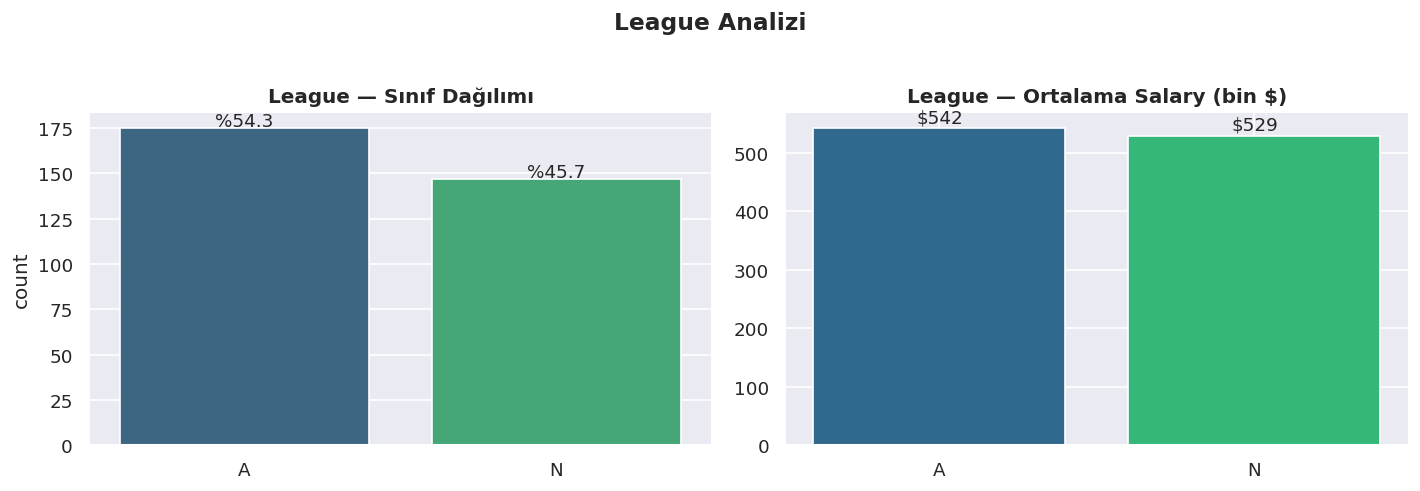

        Oyuncu Sayısı  Ort. Maaş  Medyan Maaş
League                                       
A                 139      542.0        400.0
N                 124      529.1        450.0 



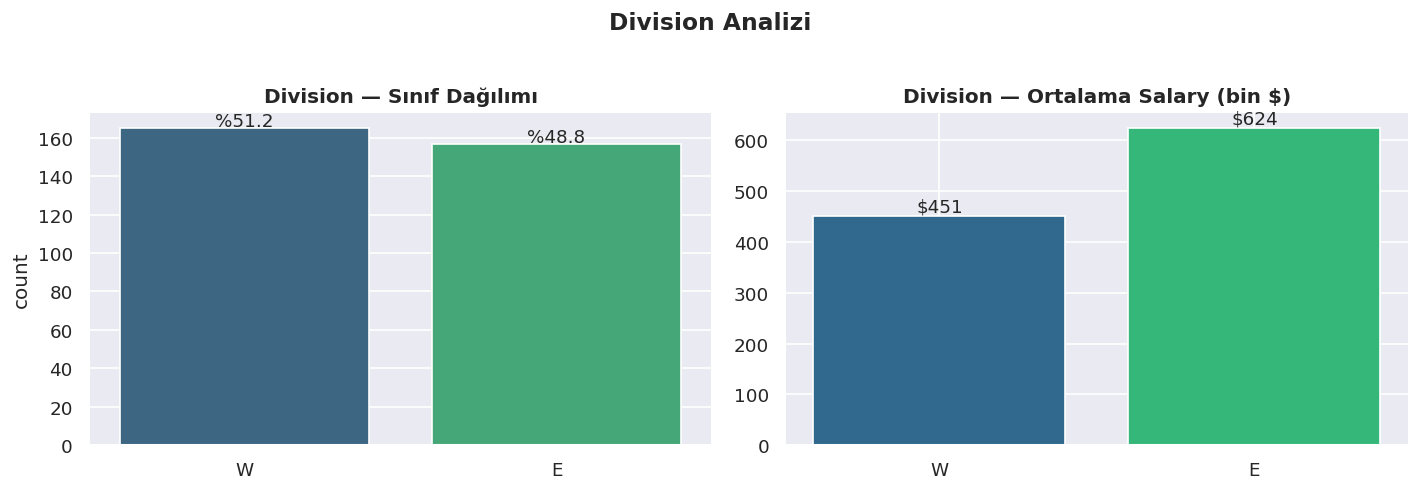

          Oyuncu Sayısı  Ort. Maaş  Medyan Maaş
Division                                       
E                   129      624.3        517.1
W                   134      450.9        375.0 



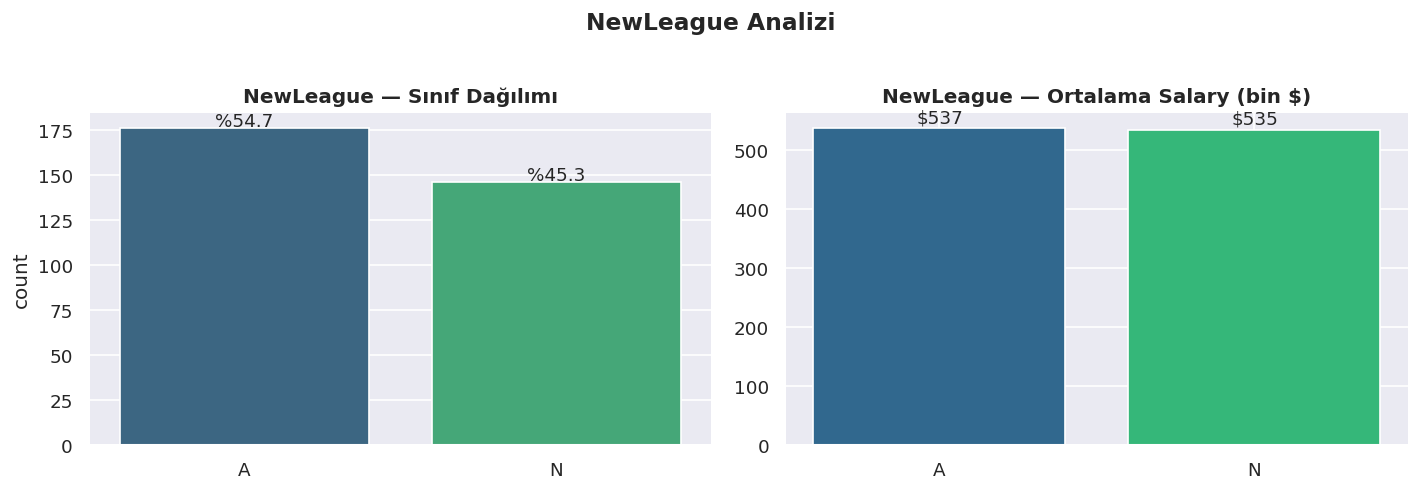

           Oyuncu Sayısı  Ort. Maaş  Medyan Maaş
NewLeague                                       
A                    141      537.1        400.0
N                    122      534.6        462.5 



In [6]:
def cat_summary(dataframe, cat_cols, target="Salary"):
    """
    Her kategorik değişken için:
    - Sınıf dağılımını (bar chart)
    - O sınıftaki ortalama Salary'yi (bar chart)
    yan yana gösterir.
    """
    for col in cat_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Sol: Sınıf frekansları
        order = dataframe[col].value_counts().index
        sns.countplot(data=dataframe, x=col, order=order,
                      palette="viridis", ax=axes[0], edgecolor="white")
        axes[0].set_title(f"{col} — Sınıf Dağılımı", fontweight="bold")
        axes[0].set_xlabel("")

        # Her barın üstüne yüzde yaz
        total = len(dataframe)
        for p in axes[0].patches:
            pct = f"%{100 * p.get_height() / total:.1f}"
            axes[0].annotate(pct,
                             (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                             ha="center", fontsize=11)

        # Sağ: Kategoriye göre ortalama Salary
        salary_means = dataframe.groupby(col)[target].mean().reindex(order)
        bars = axes[1].bar(salary_means.index, salary_means.values,
                           color=sns.color_palette("viridis", len(order)),
                           edgecolor="white")
        axes[1].set_title(f"{col} — Ortalama {target} (bin $)", fontweight="bold")
        axes[1].set_xlabel("")

        # Her barın üstüne değer yaz
        for bar, val in zip(bars, salary_means.values):
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 10,
                         f"${val:,.0f}",
                         ha="center", fontsize=11)

        plt.suptitle(f"{col} Analizi", fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

        # Özet tablo
        summary = dataframe.groupby(col)[target].agg(["count", "mean", "median"])
        summary.columns = ["Oyuncu Sayısı", "Ort. Maaş", "Medyan Maaş"]
        print(summary.round(1), "\n")

cat_summary(df, cat_cols, target="Salary")

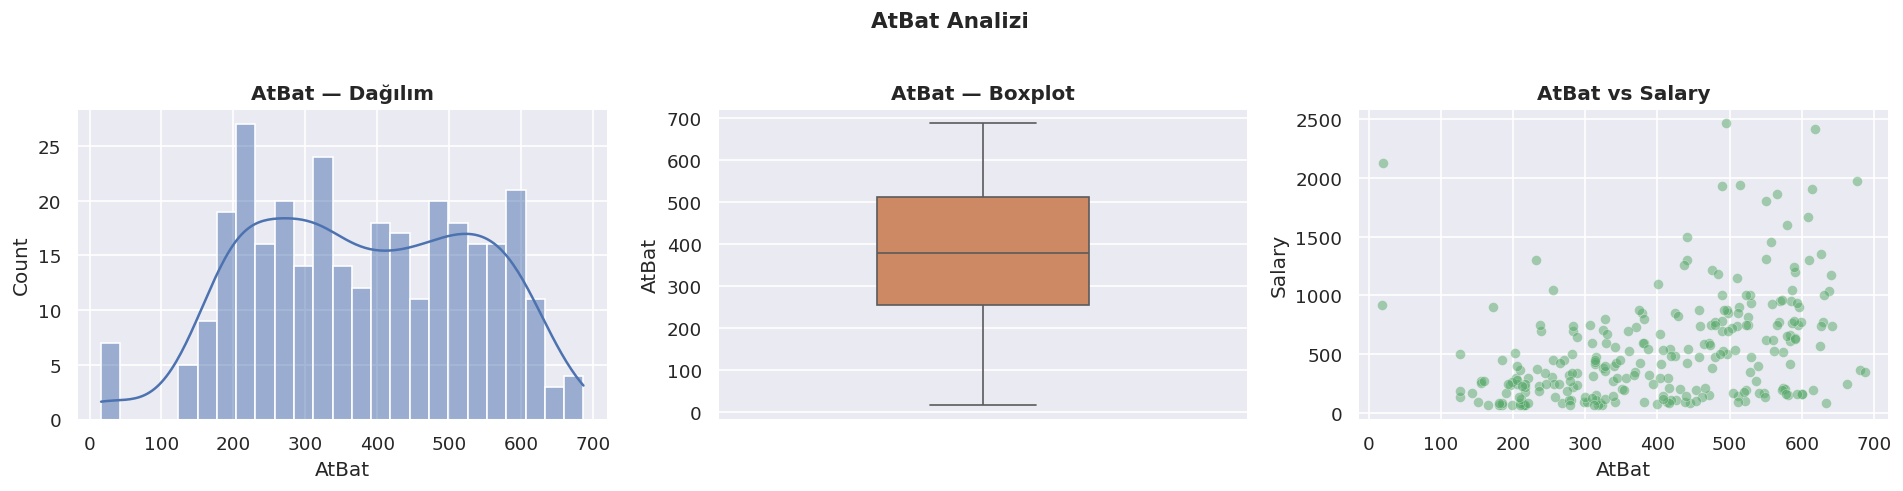

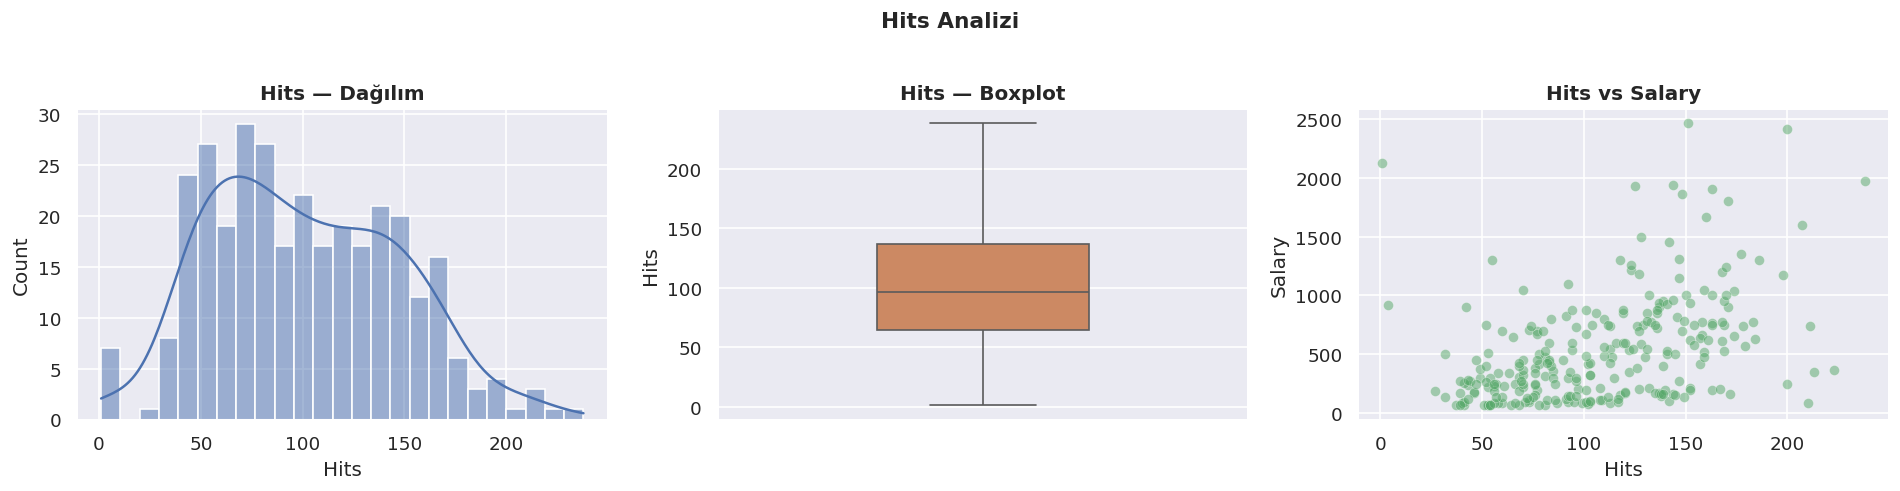

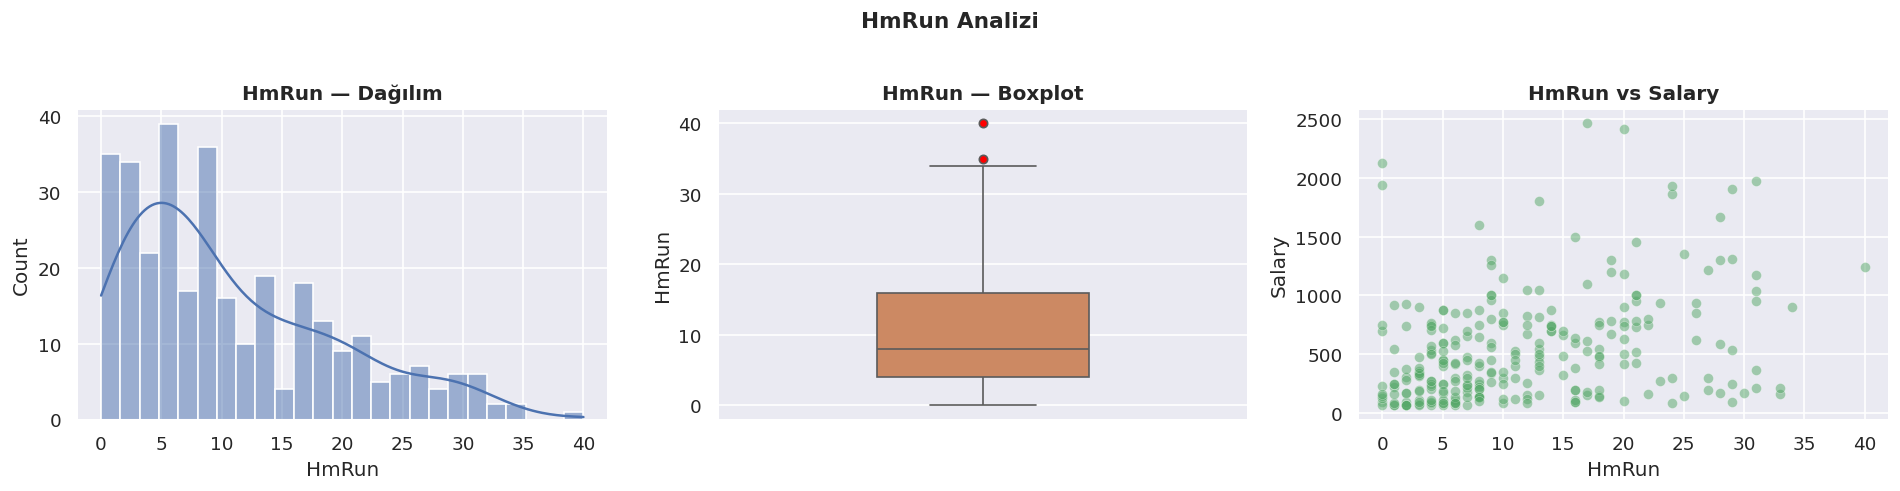

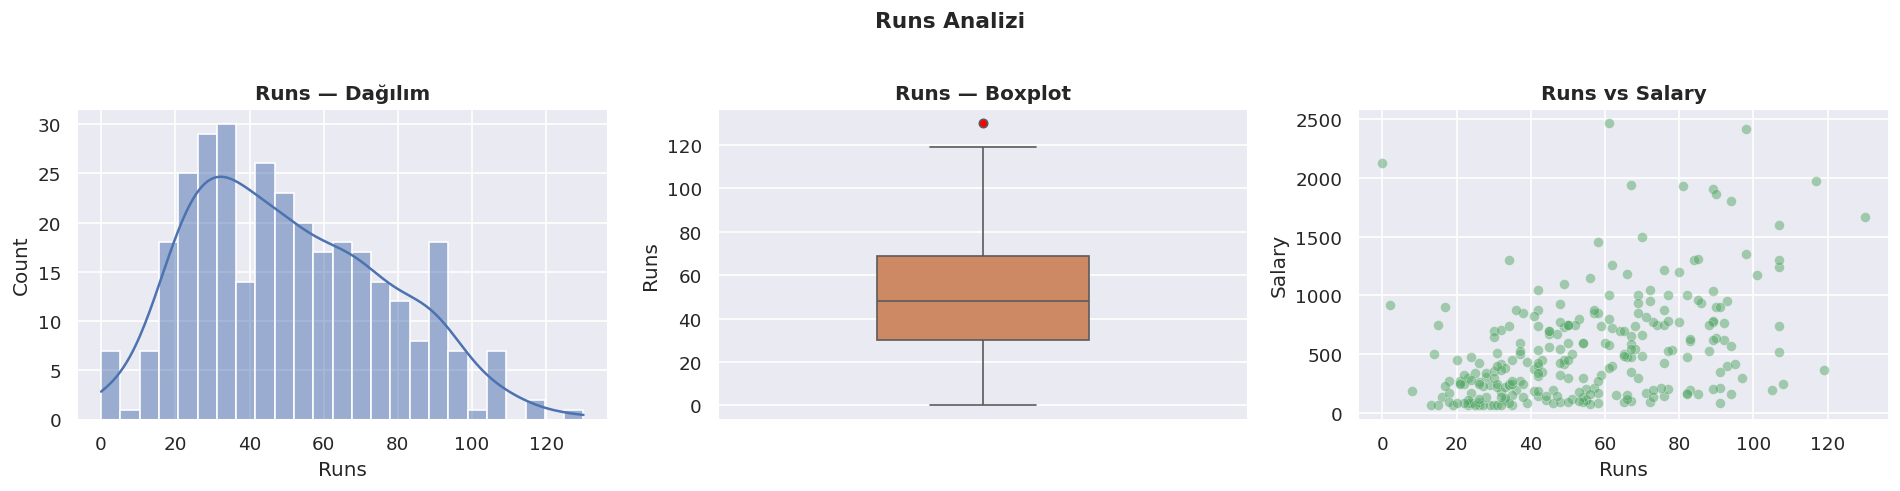

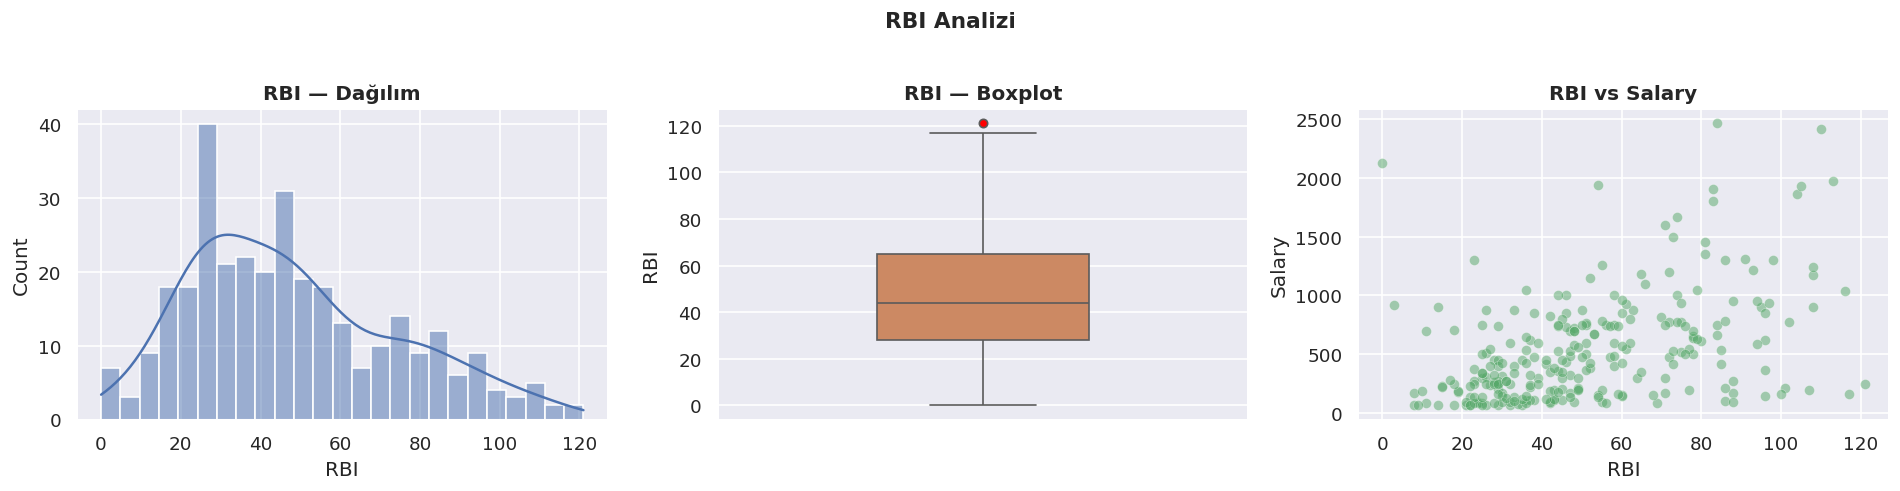

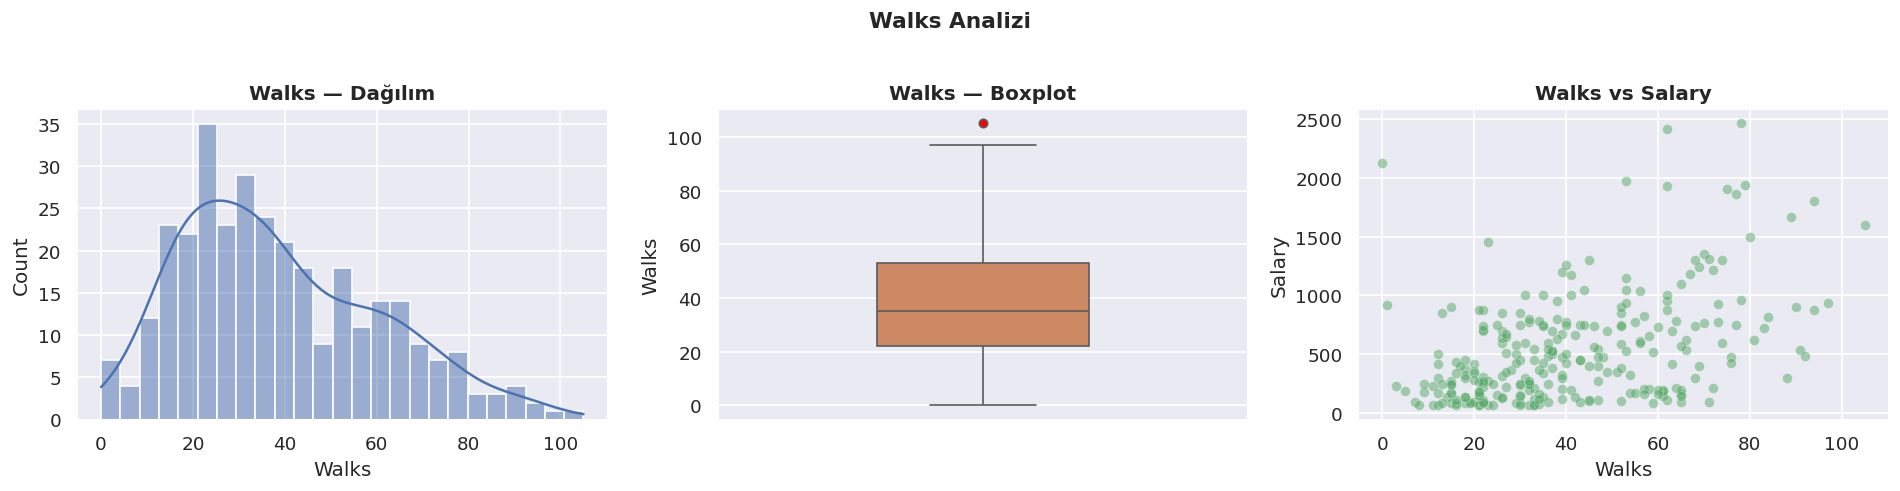

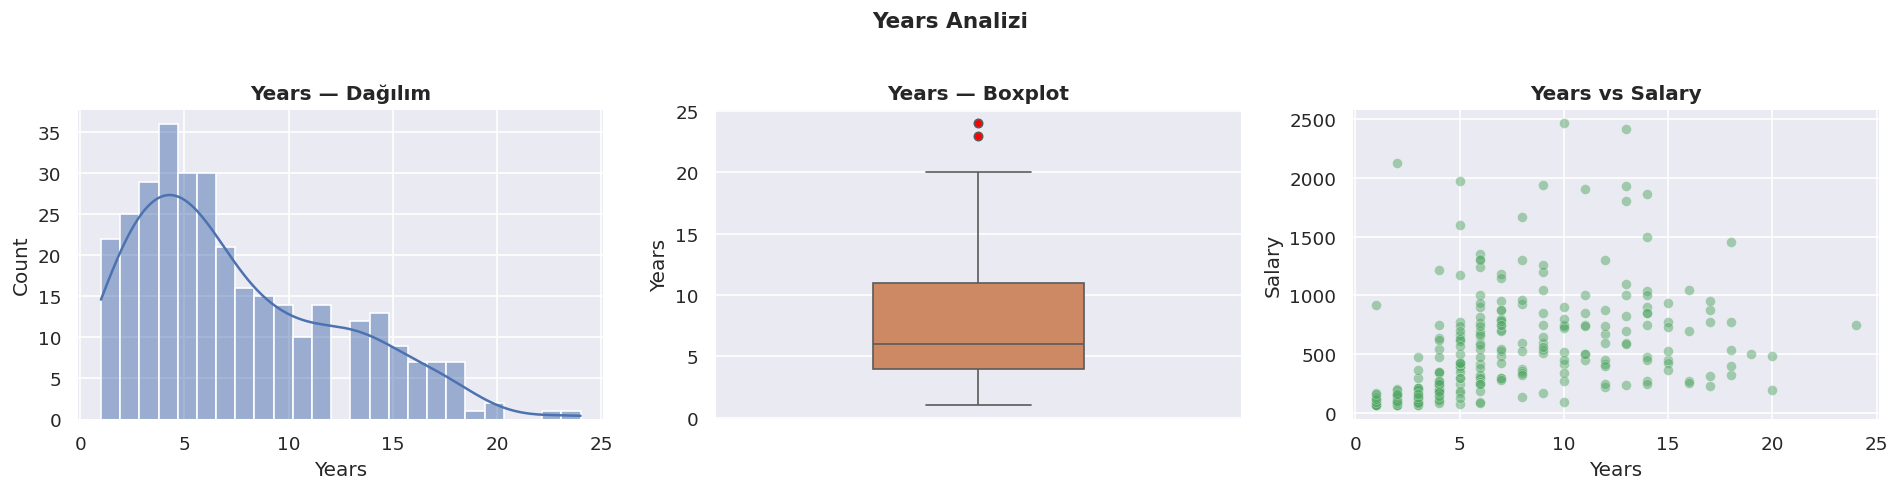

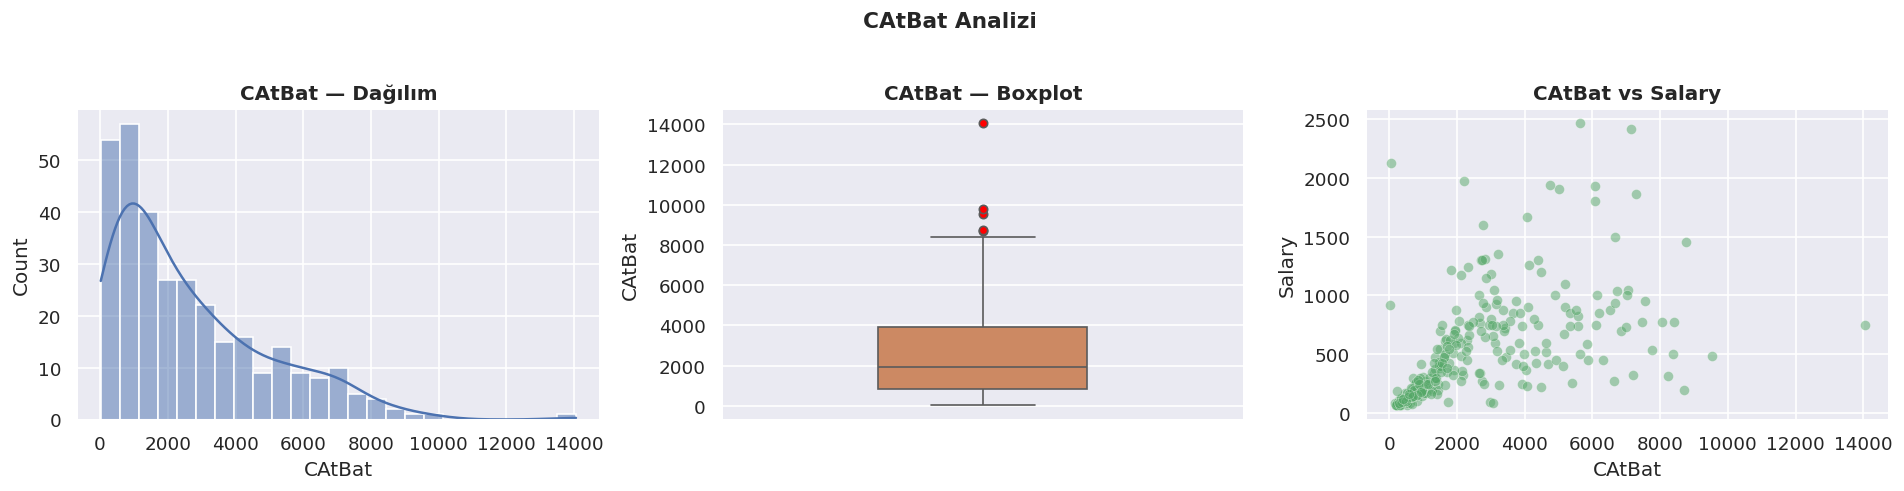

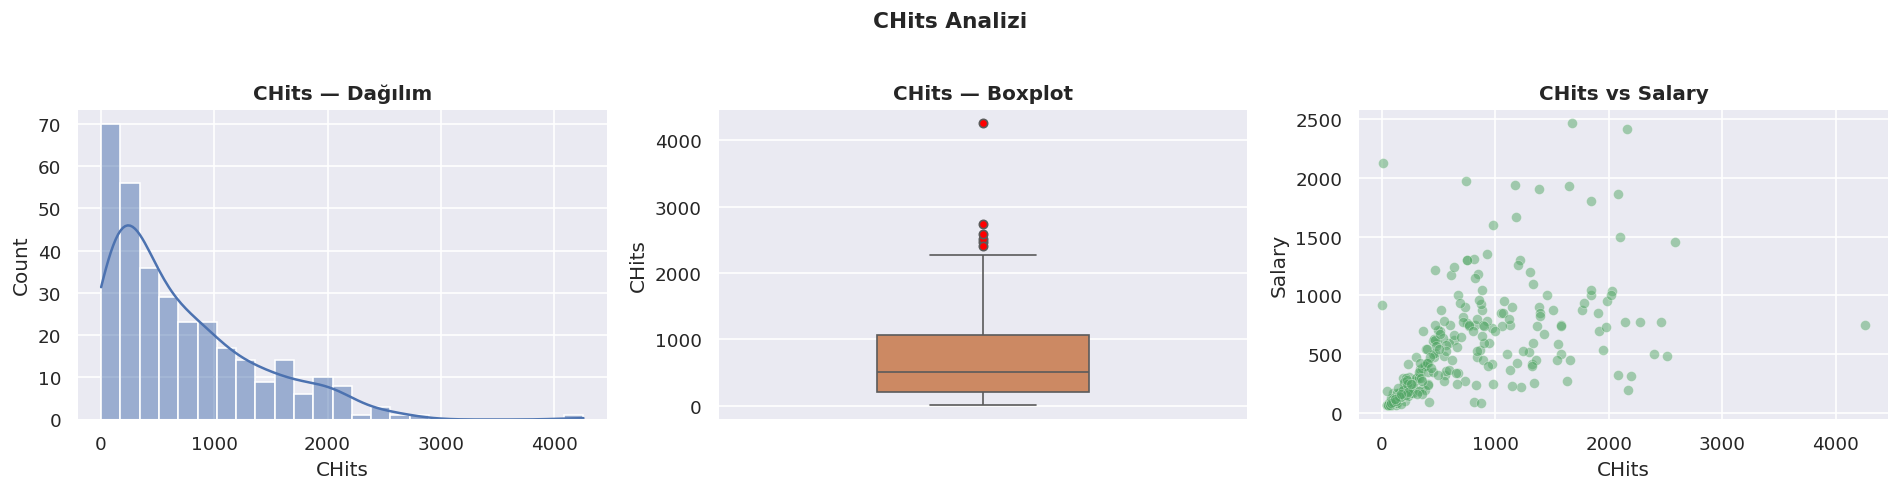

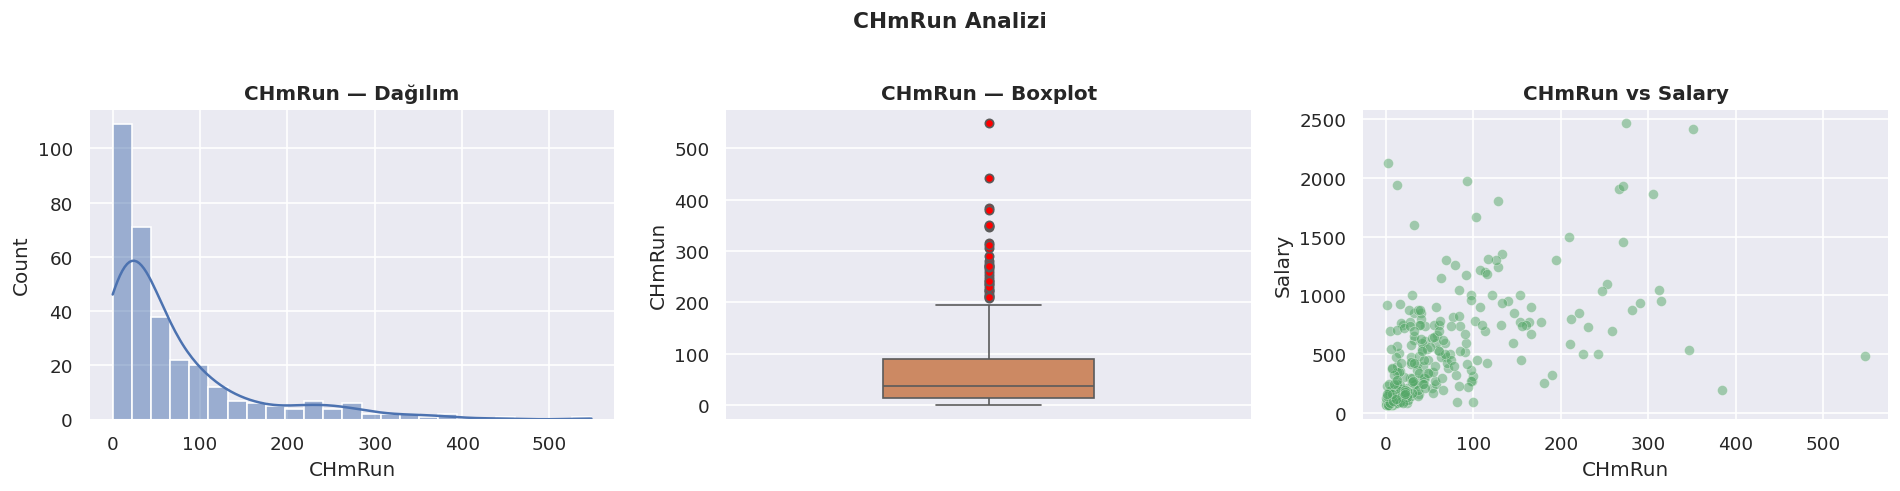

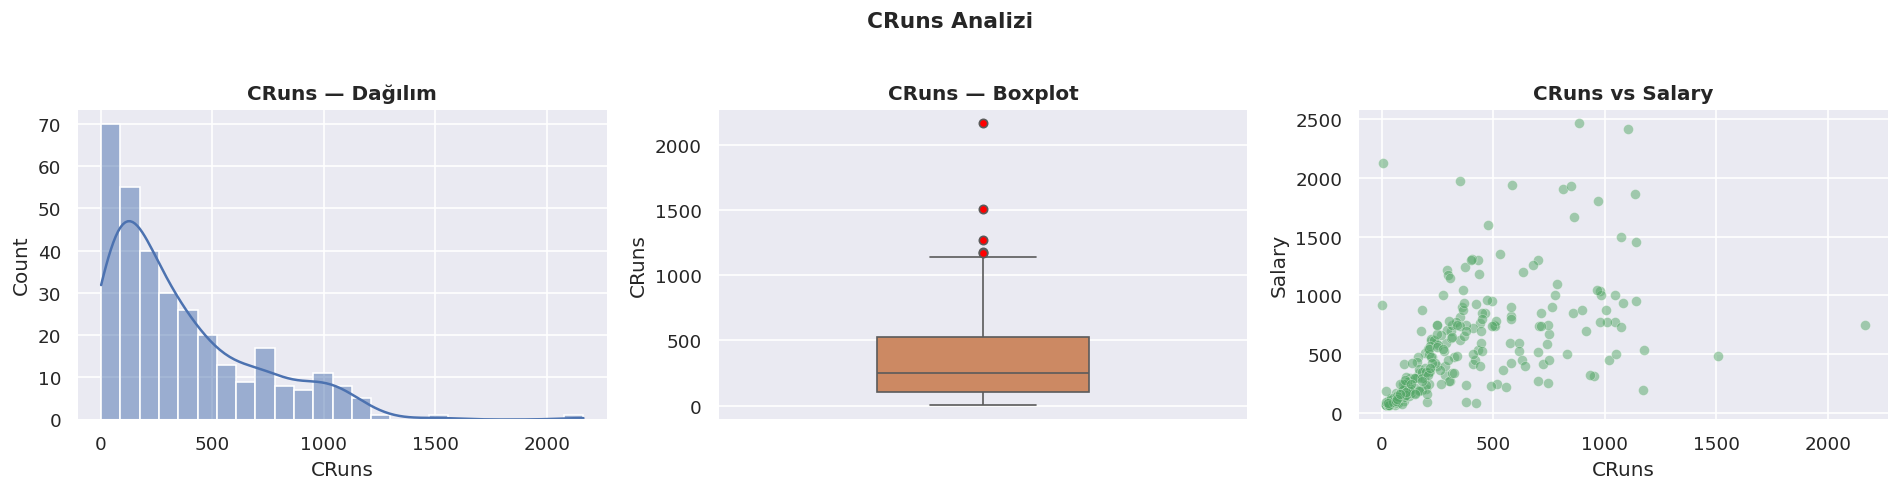

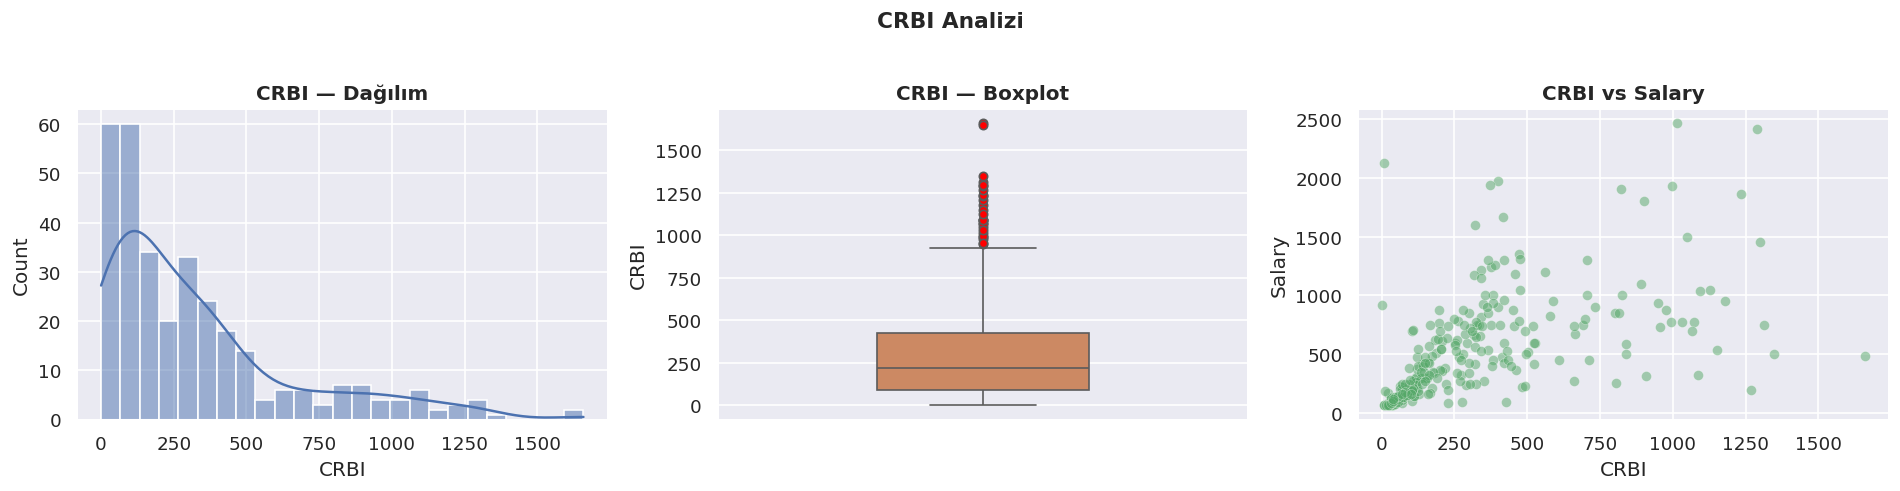

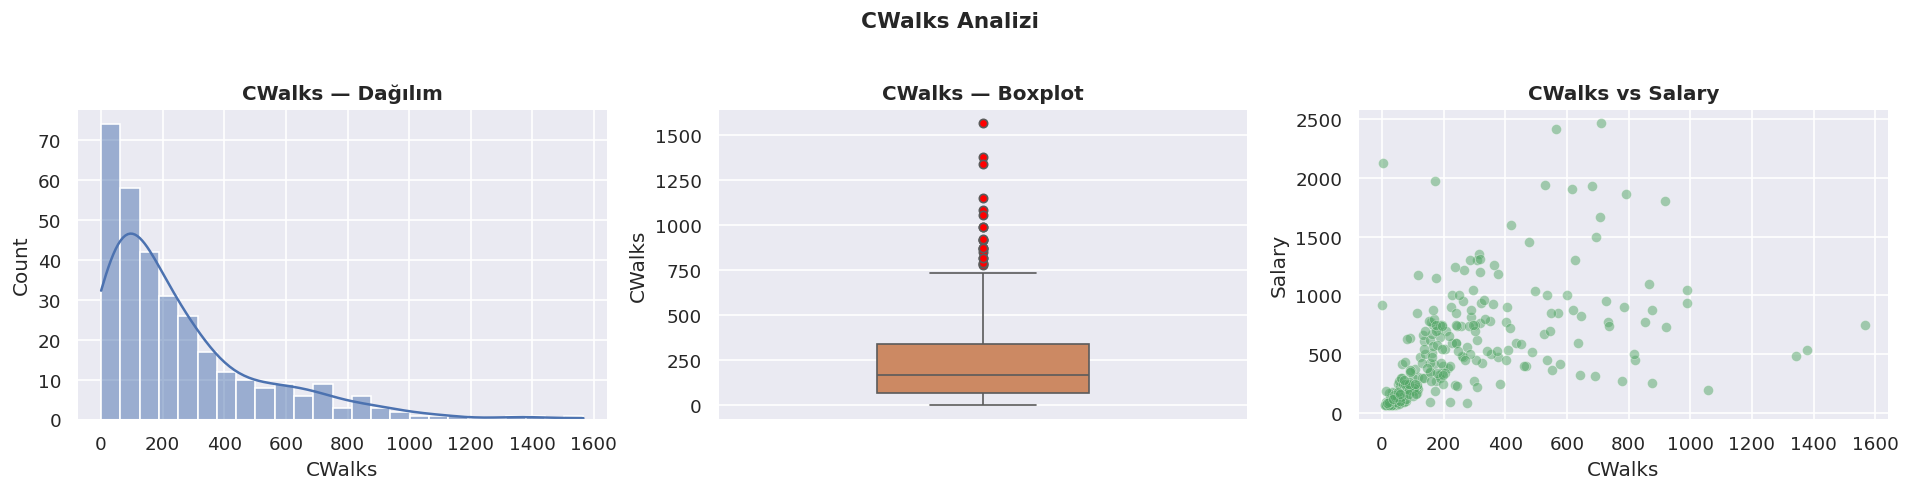

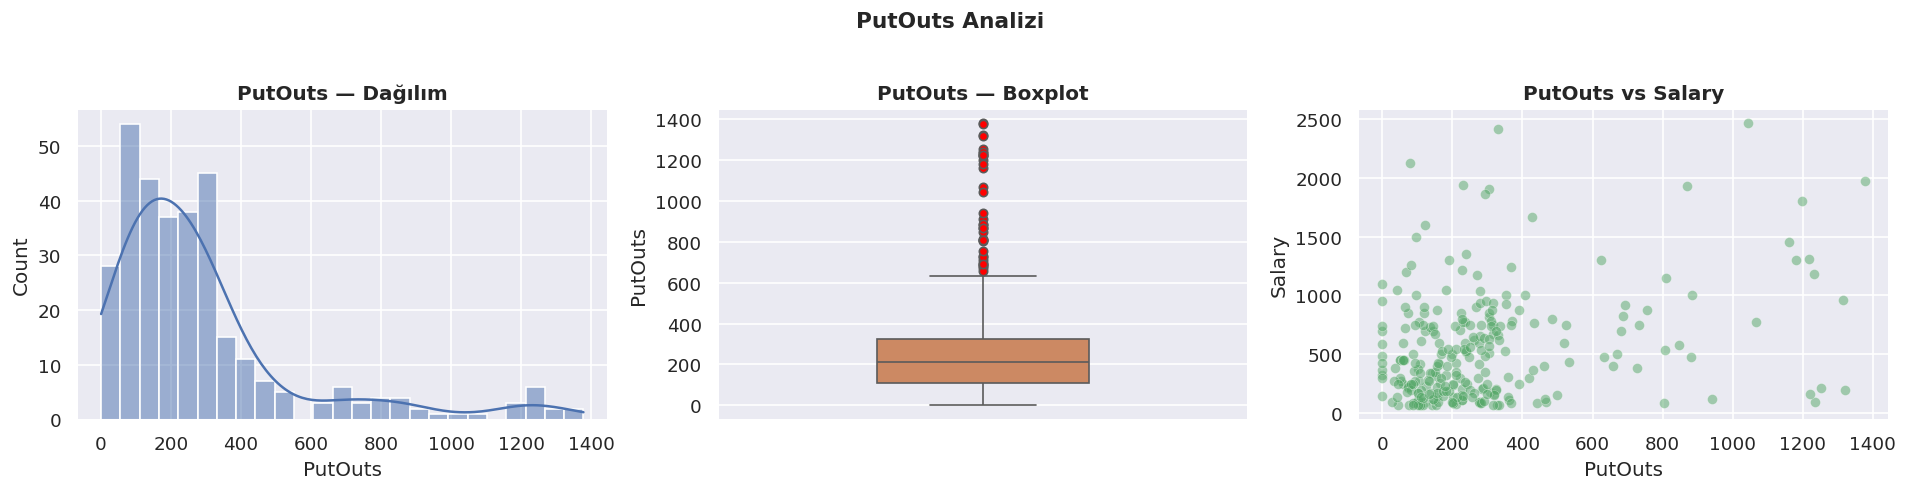

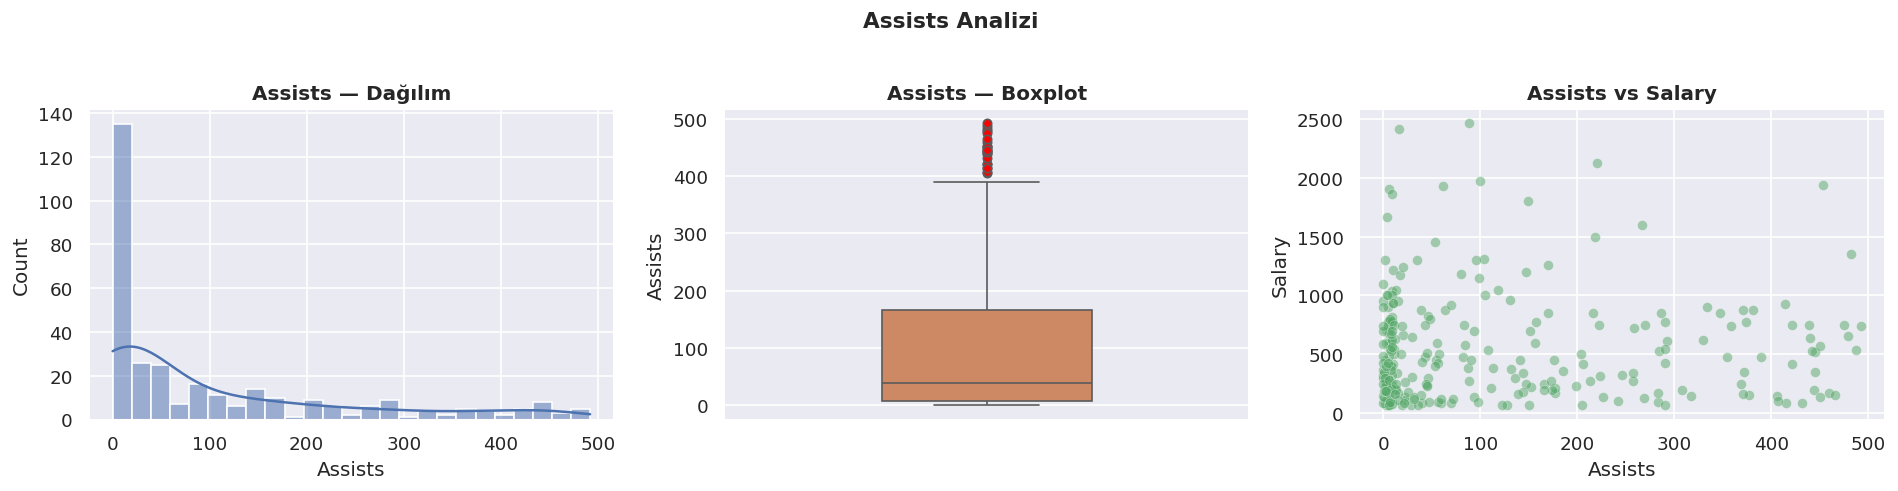

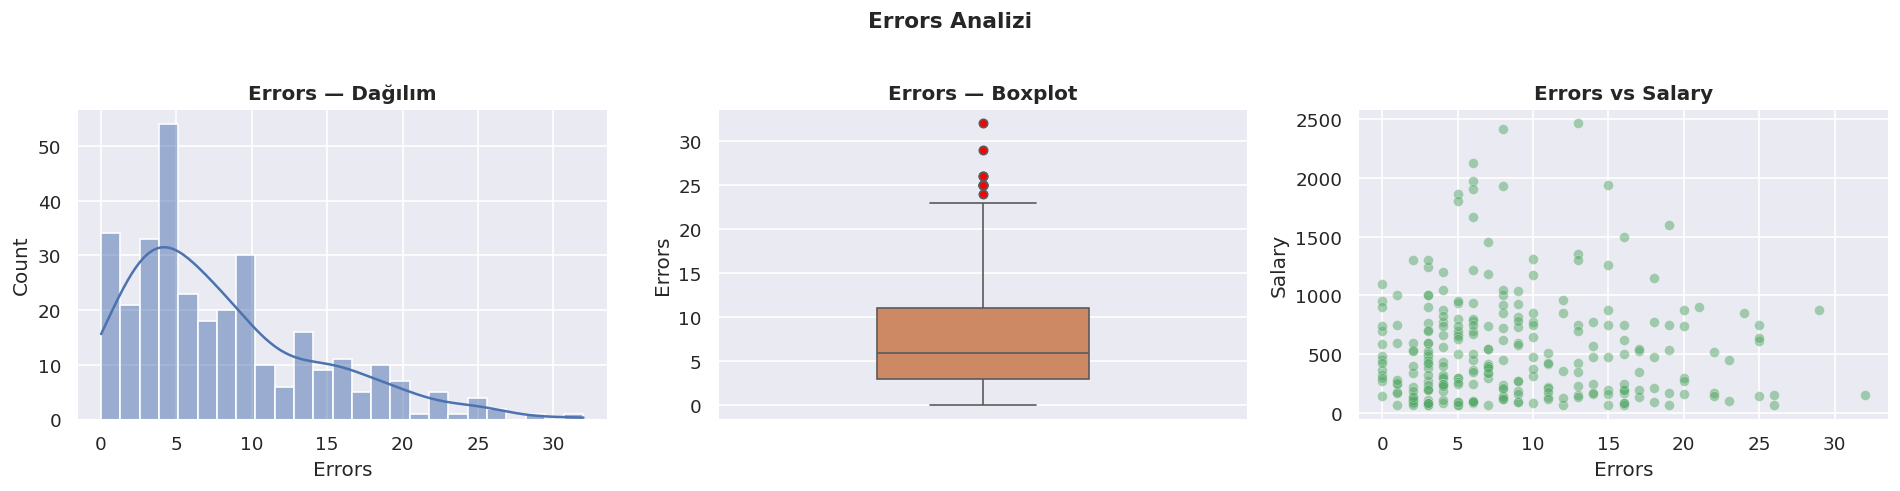

In [7]:
def num_summary(dataframe, num_cols, target="Salary"):
    """
    Her sayısal değişken için:
    - Histogram + KDE (dağılım şekli)
    - Boxplot (aykırı değer görselleştirmesi)
    - Hedef değişkenle scatter plot (ilişki)
    üç panel halinde gösterir.
    """
    for col in num_cols:
        if col == target:
            continue  # Salary'yi ayrıca analiz edeceğiz

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Panel 1: Histogram + KDE
        sns.histplot(dataframe[col].dropna(), bins=25, kde=True,
                     color="#4C72B0", ax=axes[0], edgecolor="white")
        axes[0].set_title(f"{col} — Dağılım", fontweight="bold")
        axes[0].set_xlabel(col)

        # Panel 2: Boxplot (aykırı değer tespiti)
        sns.boxplot(y=dataframe[col].dropna(), color="#DD8452",
                    ax=axes[1], width=0.4,
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
        axes[1].set_title(f"{col} — Boxplot", fontweight="bold")

        # Panel 3: Hedef değişkenle ilişki
        axes[2].scatter(dataframe[col], dataframe[target],
                        alpha=0.5, color="#55A868", edgecolors="white", linewidths=0.3)
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)
        axes[2].set_title(f"{col} vs {target}", fontweight="bold")

        plt.suptitle(f"{col} Analizi", fontsize=13, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

num_summary(df, num_cols, target="Salary")

## 🔎 EDA Bulgularımız

### Sayısal Değişkenler
| Değişken | Dağılım | Aykırı Değer | Salary ile İlişki |
|----------|---------|--------------|-------------------|
| **CAtBat, CHits, CRuns, CRBI, CWalks** | Sağa çarpık | ✅ Var | Güçlü pozitif |
| **CHmRun** | Çok sağa çarpık | ✅ Çok fazla | Orta pozitif |
| **Years** | Sağa çarpık | ✅ Var | Orta pozitif |
| **HmRun, Runs, RBI, Walks** | Hafif sağa çarpık | ✅ Az | Orta pozitif |
| **Assists, Errors** | Sağa çarpık | ✅ Var | Zayıf |

### Kategorik Değişkenler
| Değişken | Bulgu |
|----------|-------|
| **League** | A ve N ligi maaşları birbirine çok yakın (~542K vs ~529K) |
| **Division** | E division belirgin şekilde daha yüksek maaş alıyor (~624K vs ~451K) 🎯 |
| **NewLeague** | Maaş farkı yok denecek kadar az |

### Genel Çıkarımlar
- Kariyer istatistikleri (C ile başlayanlar) maaşla **daha güçlü ilişki** gösteriyor
- **Division en belirleyici kategorik değişken** — E division %38 daha fazla kazanıyor
- Salary **sağa çarpık** dağılıyor → log dönüşümü feature engineering'de işimize yarayabilir
- Pek çok değişkende **aykırı değer var** → bir sonraki adımda ele alacağız

# 🧹 4. Veri Ön İşleme

EDA'da tespit ettiğimiz sorunları burada çözüyoruz:

## Yapacaklarımız
1. **Aykırı Değer Baskılama** → IQR yöntemiyle sınıra çekme
2. **Eksik Değer Silme** → Salary'si boş satırları kaldırma

## Neden Silmiyoruz, Baskılıyoruz?
Aykırı değeri **silmek** yerine **sınır değere çekmek** tercih ediyoruz çünkü:
- Veri setimiz zaten küçük (322 satır) — veri kaybını minimize etmeliyiz
- Aykırı değer gerçek bir gözlem olabilir (gerçekten çok iyi bir oyuncu)
- Baskılama bilgiyi korur, sadece uç etkiyi törpüler

## IQR Yöntemi Nedir?
```
Q1 = %25'lik dilim
Q3 = %75'lik dilim  
IQR = Q3 - Q1

Alt Sınır = Q1 - 1.5 × IQR
Üst Sınır = Q3 + 1.5 × IQR

Bu sınırların dışındaki değerler → sınıra çekilir
```

In [8]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    """
    IQR yöntemiyle alt ve üst sınırları hesaplar.
    q1, q3 parametreleri ile sınır hassasiyeti ayarlanabilir.
    """
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    up_limit  = quartile3 + 1.5 * iqr
    low_limit = quartile1 - 1.5 * iqr
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    """Bu sütunda aykırı değer var mı? True/False döner."""
    low, up = outlier_thresholds(dataframe, col_name)
    return dataframe[(dataframe[col_name] > up) |
                     (dataframe[col_name] < low)].any(axis=None)

def replace_with_thresholds(dataframe, col_name):
    """Aykırı değerleri hesaplanan sınır değerlere çeker (baskılama)."""
    low, up = outlier_thresholds(dataframe, col_name)
    dataframe.loc[dataframe[col_name] < low, col_name] = low
    dataframe.loc[dataframe[col_name] > up, col_name]  = up

In [9]:
# Baskılama öncesi hangi sütunlarda aykırı değer var?
outlier_report = []

for col in num_cols:
    if col == "Salary":
        continue
    has_outlier = check_outlier(df, col)
    low, up = outlier_thresholds(df, col)
    n_outlier = df[(df[col] > up) | (df[col] < low)].shape[0]
    outlier_report.append({
        "Değişken"      : col,
        "Aykırı Var mı" : "✅ Evet" if has_outlier else "❌ Hayır",
        "Aykırı Sayısı" : n_outlier,
        "Alt Sınır"     : round(low, 2),
        "Üst Sınır"     : round(up, 2)
    })

outlier_df = pd.DataFrame(outlier_report)
outlier_df = outlier_df.sort_values("Aykırı Sayısı", ascending=False)
print(outlier_df.to_string(index=False))

Değişken Aykırı Var mı  Aykırı Sayısı  Alt Sınır  Üst Sınır
 PutOuts        ✅ Evet             36    -214.38     648.62
  CHmRun        ✅ Evet             32    -100.00     204.00
    CRBI        ✅ Evet             26    -417.50     932.50
 Assists        ✅ Evet             23    -231.50     404.50
  CWalks        ✅ Evet             20    -340.75     747.25
  Errors        ✅ Evet              9      -9.00      23.00
   CHits        ✅ Evet              6   -1066.38    2334.62
  CAtBat        ✅ Evet              5   -3844.50    8585.50
   CRuns        ✅ Evet              5    -538.75    1165.25
   HmRun        ✅ Evet              2     -14.00      34.00
   Years        ✅ Evet              2      -6.50      21.50
    Runs        ✅ Evet              1     -27.88     127.12
     RBI        ✅ Evet              1     -27.12     119.88
   Walks        ✅ Evet              1     -24.50      99.50
    Hits       ❌ Hayır              0     -45.50     246.50
   AtBat       ❌ Hayır              0   

/tmp/ipykernel_11514/2699551134.py:28: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


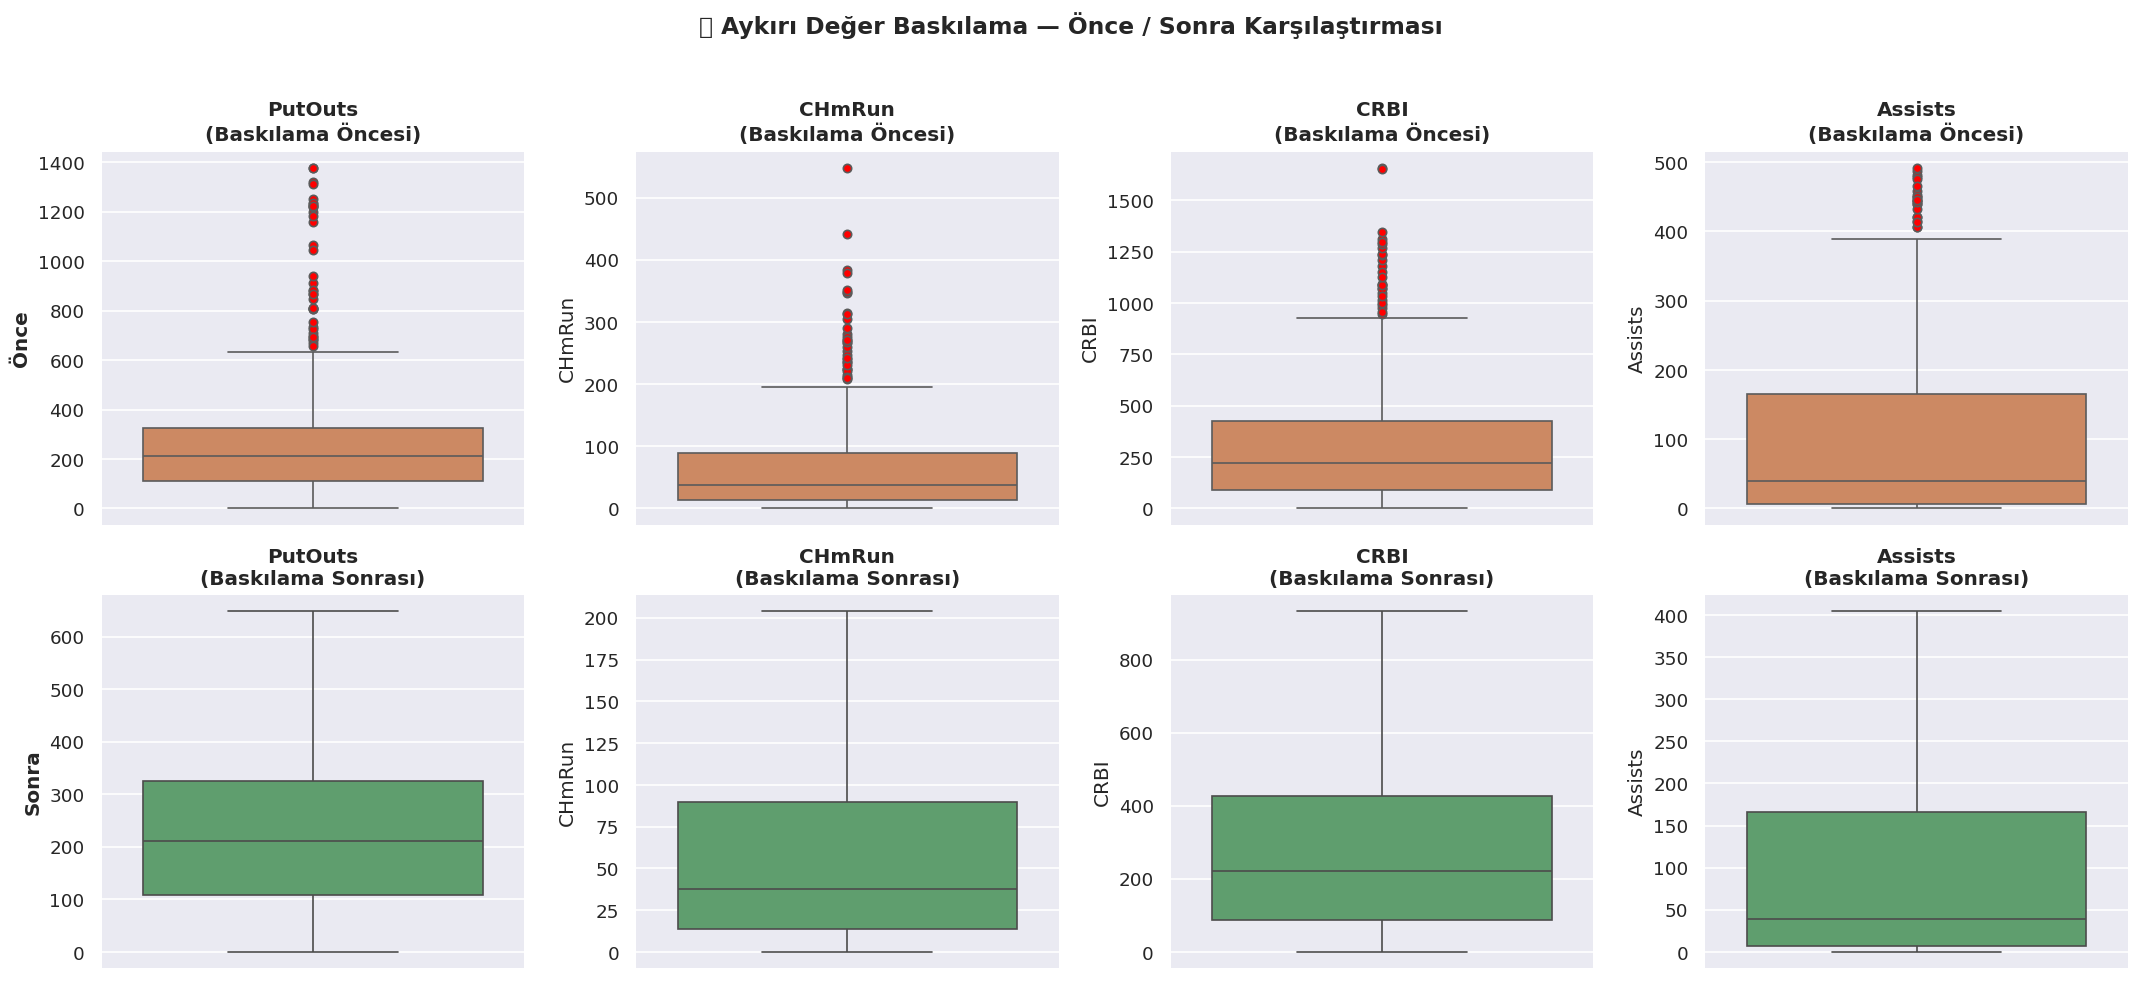

In [10]:
# Aykırı değeri en fazla olan 4 değişken için önce/sonra boxplot
top_outlier_cols = (outlier_df[outlier_df["Aykırı Sayısı"] > 0]
                    .head(4)["Değişken"]
                    .tolist())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(top_outlier_cols):
    # Önce
    sns.boxplot(y=df[col], ax=axes[0][i], color="#DD8452",
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    axes[0][i].set_title(f"{col}\n(Baskılama Öncesi)", fontweight="bold")

    # Baskılama uygula (geçici kopya üzerinde göster)
    temp = df[col].copy()
    low, up = outlier_thresholds(df, col)
    temp = temp.clip(lower=low, upper=up)

    sns.boxplot(y=temp, ax=axes[1][i], color="#55A868",
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    axes[1][i].set_title(f"{col}\n(Baskılama Sonrası)", fontweight="bold")

axes[0][0].set_ylabel("Önce", fontsize=12, fontweight="bold")
axes[1][0].set_ylabel("Sonra", fontsize=12, fontweight="bold")

plt.suptitle("🔧 Aykırı Değer Baskılama — Önce / Sonra Karşılaştırması",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Aykırı değerleri gerçekten baskılıyoruz
for col in num_cols:
    if col == "Salary":
        continue
    if check_outlier(df, col):
        replace_with_thresholds(df, col)

# Kontrol: artık aykırı değer kalmadı mı?
kalan = [col for col in num_cols if col != "Salary" and check_outlier(df, col)]
if not kalan:
    print("✅ Tüm aykırı değerler başarıyla baskılandı!")
else:
    print(f"⚠️ Hâlâ aykırı değer olan sütunlar: {kalan}")

✅ Tüm aykırı değerler başarıyla baskılandı!


In [12]:
print("Eksik Değer Durumu (Baskılama Sonrası):")
print(f"  Salary sütununda eksik: {df['Salary'].isnull().sum()} satır")
print(f"  Veri boyutu (önce) : {df.shape}")

# Salary'si eksik satırları siliyoruz
# Neden? Hedef değişkeni olmayan satırla model eğitemeyiz
# Neden doldurmuyoruz? Tahmin etmek istediğimiz şeyi kendimiz uydurmak
# modeli yanıltır — bu satırlar zaten test için de kullanılamaz
df.dropna(subset=["Salary"], inplace=True)

print(f"\n  Veri boyutu (sonra): {df.shape}")
print(f"  Silinen satır sayısı: 59")
print(f"\n✅ Veri ön işleme tamamlandı!")
print(f"   Modele gidecek temiz veri: {df.shape[0]} oyuncu × {df.shape[1]} değişken")

Eksik Değer Durumu (Baskılama Sonrası):
  Salary sütununda eksik: 59 satır
  Veri boyutu (önce) : (322, 20)

  Veri boyutu (sonra): (263, 20)
  Silinen satır sayısı: 59

✅ Veri ön işleme tamamlandı!
   Modele gidecek temiz veri: 263 oyuncu × 20 değişken


# 🏗️ 5. Özellik Mühendisliği (Feature Engineering)

Ham değişkenler bazen modele yeterli bilgiyi taşıyamaz.
Mevcut değişkenlerden **yeni ve daha anlamlı özellikler** türetmek
modelin örüntüleri daha iyi yakalamasını sağlar.

## Türeteceğimiz Özellik Kategorileri

| Kategori | Mantık | Örnek |
|----------|--------|-------|
| **Sezon/Kariyer Oranı** | Bu sezon kariyerine göre ne kadar iyi? | Hits / CHits |
| **Yıllık Ortalama** | Kariyer verimini yıla böl | CRuns / Years |
| **Etkileşim** | İki özelliğin birlikte etkisi | RBI × Walks |
| **Fark** | Bu sezon vs kariyer ortalaması | Hits - (CHits/Years) |
| **Oran** | Başarı yüzdesi | (Hits/AtBat) × 100 |

## ⚠️ Sıfıra Bölme Problemi
Bölme işlemi yapacağımız için paydanın sıfır olma ihtimaline karşı
tüm sayısal sütunlara çok küçük bir epsilon (ε) ekliyoruz.
Bu değer o kadar küçük ki gerçek sonuçları etkilemiyor.

In [13]:
# Ön işleme sonrası değişken listelerini güncelliyoruz
cat_cols, num_cols, cat_but_car = grab_col_names(df)

# Salary hariç sayısal sütunlar
new_num_cols = [col for col in num_cols if col != "Salary"]

# Sıfıra bölme hatasını önlemek için epsilon ekliyoruz
# 0.0000000001 o kadar küçük ki hiçbir analizi etkilemez
df[new_num_cols] = df[new_num_cols] + 1e-10

print(f"✅ Hazırlık tamamlandı.")
print(f"   İşlem görecek sayısal sütun sayısı: {len(new_num_cols)}")

  Toplam Değişken  : 20
  Kategorik        : 3  → ['League', 'Division', 'NewLeague']
  Sayısal          : 17  → ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary']
  Kardinal         : 0  → []
✅ Hazırlık tamamlandı.
   İşlem görecek sayısal sütun sayısı: 16


In [14]:
# =====================================================
# 1. SEZON / KARİYER ORAN ÖZELLİKLERİ
# Bu sezonki performansın kariyer ortalamasına oranı
# Yüksekse → oyuncu formda, düşükse → form düşüşü var
# =====================================================

# Bu sezonki isabetlerin kariyer isabetlerine oranı + bu sezonki isabetler
# Hem oranı hem mutlak değeri bir arada yakalamak için
df["NEW_Hits_Ratio"]   = df["Hits"]  / df["CHits"]  + df["Hits"]

# Bu sezonki RBI'ın kariyer RBI'ına oranı
df["NEW_RBI_Ratio"]    = df["RBI"]   / df["CRBI"]

# Bu sezonki walks'ın kariyer walks'ına oranı
df["NEW_Walks_Ratio"]  = df["Walks"] / df["CWalks"]

# Vuruş başarı yüzdesi: kaç vuruşta bir isabet alıyor?
df["NEW_Hit_Rate"]     = (df["Hits"] / df["AtBat"]) * 100


# =====================================================
# 2. YILLIK ORTALAMA ÖZELLİKLERİ
# Kariyer istatistiklerini yıla bölerek
# yıllık üretkenliği ölçüyoruz
# Deneyimli bir oyuncunun yıllık ortalaması daha istikrarlıdır
# =====================================================

df["NEW_CRuns_per_Year"]  = df["CRuns"]  / df["Years"]
df["NEW_CRBI_per_Year"]   = df["CRBI"]   / df["Years"]
df["NEW_CHits_per_Year"]  = df["CHits"]  / df["Years"]
df["NEW_CWalks_per_Year"] = df["CWalks"] / df["Years"]


# =====================================================
# 3. KARİYER ORAN ÖZELLİKLERİ
# Tüm kariyer boyunca ne kadar verimli?
# Toplam at-bat'a göre normalize edilmiş metrikler
# =====================================================

# Kariyer boyunca kaç vuruşta bir isabet: genel vurucu kalitesi
df["NEW_Career_Hit_Rate"]   = df["CHits"]  / df["CAtBat"]

# Kariyer boyunca kaç vuruşta bir home run: güç göstergesi
df["NEW_Career_HmRun_Rate"] = df["CHmRun"] / df["CAtBat"]


# =====================================================
# 4. ETKİLEŞİM ÖZELLİKLERİ
# İki değişkenin birlikte etkisini yakalamak için
# =====================================================

# RBI × Walks: Hem run üretiyor hem de sabırlı → değerli oyuncu
df["NEW_RBI_x_Walks"]     = df["RBI"]  * df["Walks"]

# CRBI × CAtBat: Uzun kariyer boyunca üretkenlik hacmi
df["NEW_CRBI_x_CAtBat"]   = df["CRBI"] * df["CAtBat"]

# PutOuts × Years: Savunmada deneyimle biriken katkı
df["NEW_PutOuts_x_Years"] = df["PutOuts"] * df["Years"]

# CHmRun × Years: Güç oyuncusunun uzun vadeli değeri
df["NEW_CHmRun_x_Years"]  = df["CHmRun"] * df["Years"]


# =====================================================
# 5. FARK ÖZELLİKLERİ
# Bu sezonki performans - kariyer yıllık ortalaması
# Pozitif → formda, Negatif → form düşüşünde
# =====================================================

df["NEW_Diff_AtBat"] = df["AtBat"] - (df["CAtBat"] / df["Years"])
df["NEW_Diff_Hits"]  = df["Hits"]  - (df["CHits"]  / df["Years"])
df["NEW_Diff_HmRun"] = df["HmRun"] - (df["CHmRun"] / df["Years"])
df["NEW_Diff_Runs"]  = df["Runs"]  - (df["CRuns"]  / df["Years"])
df["NEW_Diff_RBI"]   = df["RBI"]   - (df["CRBI"]   / df["Years"])
df["NEW_Diff_Walks"] = df["Walks"] - (df["CWalks"] / df["Years"])

print(f"✅ Özellik mühendisliği tamamlandı!")
print(f"   Önceki sütun sayısı : 20")
print(f"   Yeni sütun sayısı   : {df.shape[1]}")
print(f"   Türetilen özellik   : {df.shape[1] - 20}")

✅ Özellik mühendisliği tamamlandı!
   Önceki sütun sayısı : 20
   Yeni sütun sayısı   : 40
   Türetilen özellik   : 20


/tmp/ipykernel_11514/1531048427.py:22: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


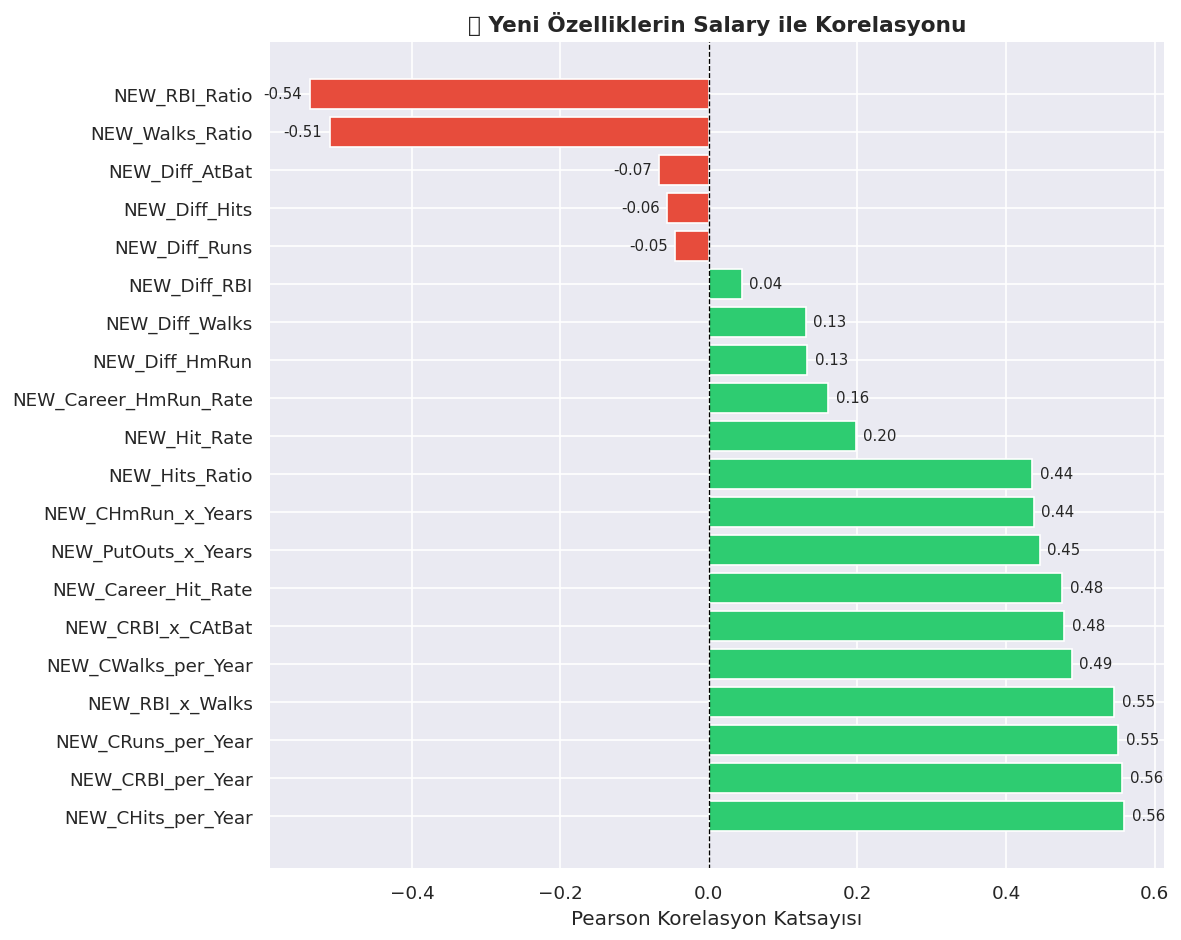


🏆 Salary ile En Güçlü İlişkili Yeni Özellikler:
NEW_CHits_per_Year     0.559435
NEW_CRBI_per_Year      0.556316
NEW_CRuns_per_Year     0.551379
NEW_RBI_x_Walks        0.545722
NEW_CWalks_per_Year    0.488562


In [15]:
# Yeni türetilen özelliklerin Salary ile ne kadar ilişkili olduğunu görelim
new_features = [col for col in df.columns if col.startswith("NEW_")]

corr_new = (df[new_features + ["Salary"]]
            .corr()["Salary"]
            .drop("Salary")
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in corr_new.values]
ax.barh(corr_new.index, corr_new.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("🆕 Yeni Özelliklerin Salary ile Korelasyonu",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Korelasyon Katsayısı")

for i, v in enumerate(corr_new.values):
    ax.text(v + 0.01 if v > 0 else v - 0.01,
            i, f"{v:.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

# En güçlü 5 yeni özellik
print("\n🏆 Salary ile En Güçlü İlişkili Yeni Özellikler:")
print(corr_new.head().to_string())

## 🔎 Feature Engineering Bulgularımız

### En Güçlü Yeni Özellikler
| Özellik | Korelasyon | Yorumu |
|---------|-----------|--------|
| **NEW_CHits_per_Year** | 0.559 | Yıllık ortalama kariyer isabeti — istikrarlı oyuncuyu ödüllendiriyor |
| **NEW_CRBI_per_Year** | 0.556 | Yıllık ortalama RBI — üretkenliğin en saf göstergesi |
| **NEW_CRuns_per_Year** | 0.551 | Yıllık koşu katkısı — takım değerini ölçüyor |
| **NEW_RBI_x_Walks** | 0.546 | Üretkenlik × Sabır — kaliteli vurucunun bileşik skoru |
| **NEW_CWalks_per_Year** | 0.489 | Yıllık disiplin göstergesi |

### 💡 Kritik Çıkarım
Ham kariyer istatistikleri (CHits, CRBI...) maaşla ilişkiliydi ama
**yıla bölünce daha güçlü** ilişki çıktı!

Neden? Çünkü 10 yılda 1000 isabetli oyuncu ile
5 yılda 1000 isabetli oyuncu **aynı değerde değil.**
Yıllık ortalama, oyuncunun **gerçek üretkenliğini** daha iyi yansıtıyor.

# 🔄 6. Encoding & Ölçeklendirme

Makine öğrenmesi modelleri sadece **sayısal verilerle** çalışır.
Bu adımda iki şey yapıyoruz:

## 1. One-Hot Encoding
Kategorik değişkenleri (League, Division, NewLeague) sayıya çeviriyoruz.

**Neden One-Hot?**
- Bu değişkenlerin sınıfları arasında bir sıra/büyüklük ilişkisi yok
- Label Encoding (0, 1, 2) yaparsak model aralarında
  büyüklük ilişkisi varmış gibi algılar — yanlış!
- One-Hot her sınıfı ayrı bir 0/1 sütununa dönüştürür

**Neden drop_first=True?**
- League: A ve N → sadece 1 sütun yeterli (N=0 ise A demek)
- 2 sütun yapmak gereksiz bilgi tekrarı yaratır (dummy variable trap)

## 2. StandardScaler
Sayısal değişkenleri aynı ölçeğe getiriyoruz.

**Neden?**
- KNN, SVR gibi uzaklık bazlı modeller büyük değerli
  değişkenlere haksız ağırlık verir
- CAtBat (19-14053) ile Years (1-24) aynı ölçekte değil
- StandardScaler → ortalama=0, std=1

**⚠️ Salary ölçeklendirilmez!**
Hedef değişkeni dönüştürürsek tahminleri geri çevirmemiz gerekir,
gereksiz karmaşıklık yaratır.

In [16]:
# Encoding öncesi durumu görelim
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print("Encoding Öncesi:")
print(f"  Toplam sütun     : {df.shape[1]}")
print(f"  Kategorik sütun  : {cat_cols}")
print(f"\n  Örnek değerler:")
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

# One-Hot Encoding uyguluyoruz
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f"\nEncoding Sonrası:")
print(f"  Toplam sütun     : {df.shape[1]}")
print(f"  Eklenen sütunlar : {[c for c in df.columns if any(c.startswith(cat) for cat in ['League','Division','NewLeague'])]}")
df.head(3)

  Toplam Değişken  : 40
  Kategorik        : 3  → ['League', 'Division', 'NewLeague']
  Sayısal          : 37  → ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NEW_Hits_Ratio', 'NEW_RBI_Ratio', 'NEW_Walks_Ratio', 'NEW_Hit_Rate', 'NEW_CRuns_per_Year', 'NEW_CRBI_per_Year', 'NEW_CHits_per_Year', 'NEW_CWalks_per_Year', 'NEW_Career_Hit_Rate', 'NEW_Career_HmRun_Rate', 'NEW_RBI_x_Walks', 'NEW_CRBI_x_CAtBat', 'NEW_PutOuts_x_Years', 'NEW_CHmRun_x_Years', 'NEW_Diff_AtBat', 'NEW_Diff_Hits', 'NEW_Diff_HmRun', 'NEW_Diff_Runs', 'NEW_Diff_RBI', 'NEW_Diff_Walks']
  Kardinal         : 0  → []
Encoding Öncesi:
  Toplam sütun     : 40
  Kategorik sütun  : ['League', 'Division', 'NewLeague']

  Örnek değerler:
  League: ['N' 'A']
  Division: ['W' 'E']
  NewLeague: ['N' 'A']

Encoding Sonrası:
  Toplam sütun     : 40
  Eklenen sütunlar : ['League_N', 'Division_W', 'NewLeague_N']


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,...,NEW_CHmRun_x_Years,NEW_Diff_AtBat,NEW_Diff_Hits,NEW_Diff_HmRun,NEW_Diff_Runs,NEW_Diff_RBI,NEW_Diff_Walks,League_N,Division_W,NewLeague_N
1,315.0,81.0,7.0,24.0,38.0,39.0,14.0,3449.0,835.0,69.0,...,966.0,68.642857,21.357143,2.071429,1.071429,8.428571,12.214286,1,1,1
2,479.0,130.0,18.0,66.0,72.0,76.0,3.0,1624.0,457.0,63.0,...,189.0,-62.333333,-22.333333,-3.000000,-8.666667,-16.666667,-11.666667,0,1,0
3,496.0,141.0,20.0,65.0,78.0,37.0,11.0,5628.0,1575.0,204.0,...,2244.0,-15.636364,-2.181818,1.454545,-10.272727,1.818182,4.818182,1,0,1


In [17]:
# Encoding sonrası değişken listelerini güncelliyoruz
cat_cols, num_cols, cat_but_car = grab_col_names(df)

# Salary'yi ölçeklendirme dışında tutuyoruz
num_cols_to_scale = [col for col in num_cols if col != "Salary"]

# Ölçeklendirme öncesi dağılım
print("Ölçeklendirme Öncesi (ilk 3 sayısal sütun):")
print(df[num_cols_to_scale[:3]].describe().loc[["mean", "std", "min", "max"]].round(2))

# StandardScaler uyguluyoruz
scaler = StandardScaler()
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print("\nÖlçeklendirme Sonrası (ilk 3 sayısal sütun):")
print(df[num_cols_to_scale[:3]].describe().loc[["mean", "std", "min", "max"]].round(2))

print(f"\n✅ {len(num_cols_to_scale)} sayısal değişken ölçeklendirildi.")
print(f"   Salary dokunulmadı → min: {df['Salary'].min():.1f}, max: {df['Salary'].max():.1f}")

  Toplam Değişken  : 40
  Kategorik        : 3  → ['League_N', 'Division_W', 'NewLeague_N']
  Sayısal          : 37  → ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NEW_Hits_Ratio', 'NEW_RBI_Ratio', 'NEW_Walks_Ratio', 'NEW_Hit_Rate', 'NEW_CRuns_per_Year', 'NEW_CRBI_per_Year', 'NEW_CHits_per_Year', 'NEW_CWalks_per_Year', 'NEW_Career_Hit_Rate', 'NEW_Career_HmRun_Rate', 'NEW_RBI_x_Walks', 'NEW_CRBI_x_CAtBat', 'NEW_PutOuts_x_Years', 'NEW_CHmRun_x_Years', 'NEW_Diff_AtBat', 'NEW_Diff_Hits', 'NEW_Diff_HmRun', 'NEW_Diff_Runs', 'NEW_Diff_RBI', 'NEW_Diff_Walks']
  Kardinal         : 0  → []
Ölçeklendirme Öncesi (ilk 3 sayısal sütun):
       AtBat    Hits  HmRun
mean  403.64  107.83  11.60
std   147.31   45.13   8.69
min    19.00    1.00   0.00
max   687.00  238.00  34.00

Ölçeklendirme Sonrası (ilk 3 sayısal sütun):
      AtBat  Hits  HmRun
mean  -0.00 -0.00  -0.00
std    1.00  1.00  

  MODELİN GÖRECEĞİ VERİ — SON DURUM
  Özellik sayısı (X) : 39
  Gözlem sayısı      : 263
  Hedef (y) aralığı  : 67.5K$ — 2460.0K$
  Hedef (y) ortalaması: 535.9K$

  Orijinal özellikler  : 16
  Türetilen özellikler : 20
  Encoded özellikler   : 3


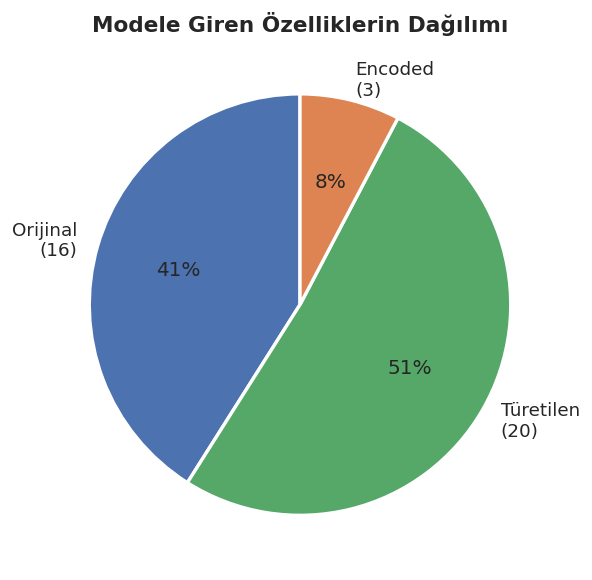

In [18]:
# Modele gidecek verinin son hali
y = df["Salary"]
X = df.drop("Salary", axis=1)

print("=" * 45)
print("  MODELİN GÖRECEĞİ VERİ — SON DURUM")
print("=" * 45)
print(f"  Özellik sayısı (X) : {X.shape[1]}")
print(f"  Gözlem sayısı      : {X.shape[0]}")
print(f"  Hedef (y) aralığı  : {y.min():.1f}K$ — {y.max():.1f}K$")
print(f"  Hedef (y) ortalaması: {y.mean():.1f}K$")

# Özellik kategorileri
original   = [c for c in X.columns if not c.startswith("NEW_") and
              not any(c.startswith(x) for x in ["League","Division","NewLeague"])]
engineered = [c for c in X.columns if c.startswith("NEW_")]
encoded    = [c for c in X.columns if any(c.startswith(x)
              for x in ["League","Division","NewLeague"])]

print(f"\n  Orijinal özellikler  : {len(original)}")
print(f"  Türetilen özellikler : {len(engineered)}")
print(f"  Encoded özellikler   : {len(encoded)}")

# Pasta grafik
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    [len(original), len(engineered), len(encoded)],
    labels=[f"Orijinal\n({len(original)})",
            f"Türetilen\n({len(engineered)})",
            f"Encoded\n({len(encoded)})"],
    autopct="%1.0f%%",
    colors=["#4C72B0", "#55A868", "#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax.set_title("Modele Giren Özelliklerin Dağılımı",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## ✅ Encoding & Ölçeklendirme Tamamlandı

### Veri Durumu
| | Önce | Sonra |
|--|------|-------|
| **Satır** | 322 | 263 (59 eksik Salary silindi) |
| **Sütun** | 20 | 40 |
| **Kategorik** | 3 | 0 (encode edildi) |
| **Sayısal** | 17 | 39 |

### Özellik Dağılımı
| Tür | Sayı | Açıklama |
|-----|------|----------|
| Orijinal | 16 | Ham veri değişkenleri |
| Türetilen | 20 | Feature engineering ile üretilen |
| Encoded | 3 | Kategorik → 0/1 |
| **Toplam** | **39** | Modele girecek özellik sayısı |

### Ölçeklendirme Kontrolü ✅
- Tüm sayısal değişkenler → ortalama ≈ 0, std = 1
- Salary dokunulmadı → 67.5K$ — 2460K$ aralığında

# 🤖 7. Model Karşılaştırması

Hiperparametre optimizasyonu yapmadan önce tüm modelleri
**varsayılan ayarlarla** karşılaştırıyoruz.

## Neden Base Model Karşılaştırması?
- Hangi model ailesi bu veri için uygun? → Görmek için
- Optimizasyonun ne kadar kazandırdığını ölçmek için referans nokta
- Gereksiz modelleri eleyip sadece iyilere odaklanmak için

## Metrik: RMSE (Root Mean Squared Error)

RMSE = √(Σ(gerçek - tahmin)² / n)

- Birimi hedef değişkenle aynı → bin $ cinsinden hata
- **Düşük RMSE = daha iyi model**
- Büyük hataları daha çok cezalandırır (kare aldığı için)

## Cross-Validation (cv=10) Nedir?
Veriyi 10 eşit parçaya böleriz:
- 9 parça → eğitim
- 1 parça → test
- Bu işlemi 10 kez tekrarlarız, her seferinde farklı parça test olur
- 10 RMSE'nin ortalamasını alırız

**Neden?** Tek bir train/test split şansa bağlı olabilir.
CV ile modelin **gerçek genelleme performansını** ölçürüz.

In [19]:
# X ve y zaten bir önceki adımda tanımlandı
# Hatırlatma:
# y = df["Salary"]
# X = df.drop("Salary", axis=1)

models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge",             Ridge()),
    ("Lasso",             Lasso()),
    ("ElasticNet",        ElasticNet()),
    ("KNN",               KNeighborsRegressor()),
    ("CART",              DecisionTreeRegressor()),
    ("Random Forest",     RandomForestRegressor()),
    ("SVR",               SVR()),
    ("GBM",               GradientBoostingRegressor()),
    ("XGBoost",           XGBRegressor(objective="reg:squarederror", verbosity=0)),
    ("LightGBM",          LGBMRegressor(verbose=-1)),
    ("CatBoost",          CatBoostRegressor(verbose=False))
]

print("⏳ Modeller değerlendiriliyor...\n")
print(f"{'Model':<22} {'RMSE':>10}")
print("-" * 35)

results = {}
for name, model in models:
    scores = np.sqrt(-cross_val_score(model, X, y,
                                      cv=10,
                                      scoring="neg_mean_squared_error"))
    rmse = scores.mean()
    std  = scores.std()
    results[name] = {"RMSE": rmse, "STD": std}
    print(f"  {name:<20} {rmse:>8.2f}  (±{std:.2f})")

print("-" * 35)
best_name = min(results, key=lambda x: results[x]["RMSE"])
print(f"\n🏆 En İyi Base Model: {best_name} → RMSE: {results[best_name]['RMSE']:.2f}")

⏳ Modeller değerlendiriliyor...

Model                        RMSE
-----------------------------------
  Linear Regression      273.75  (±67.78)
  Ridge                  267.18  (±69.05)
  Lasso                  271.42  (±72.16)
  ElasticNet             298.71  (±96.02)
  KNN                    294.02  (±94.04)
  CART                   302.07  (±64.99)
  Random Forest          237.59  (±86.12)
  SVR                    441.80  (±113.79)
  GBM                    244.62  (±79.66)
  XGBoost                273.33  (±77.41)
  LightGBM               264.36  (±91.95)
  CatBoost               243.66  (±90.99)
-----------------------------------

🏆 En İyi Base Model: Random Forest → RMSE: 237.59


/tmp/ipykernel_11514/3285781925.py:30: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


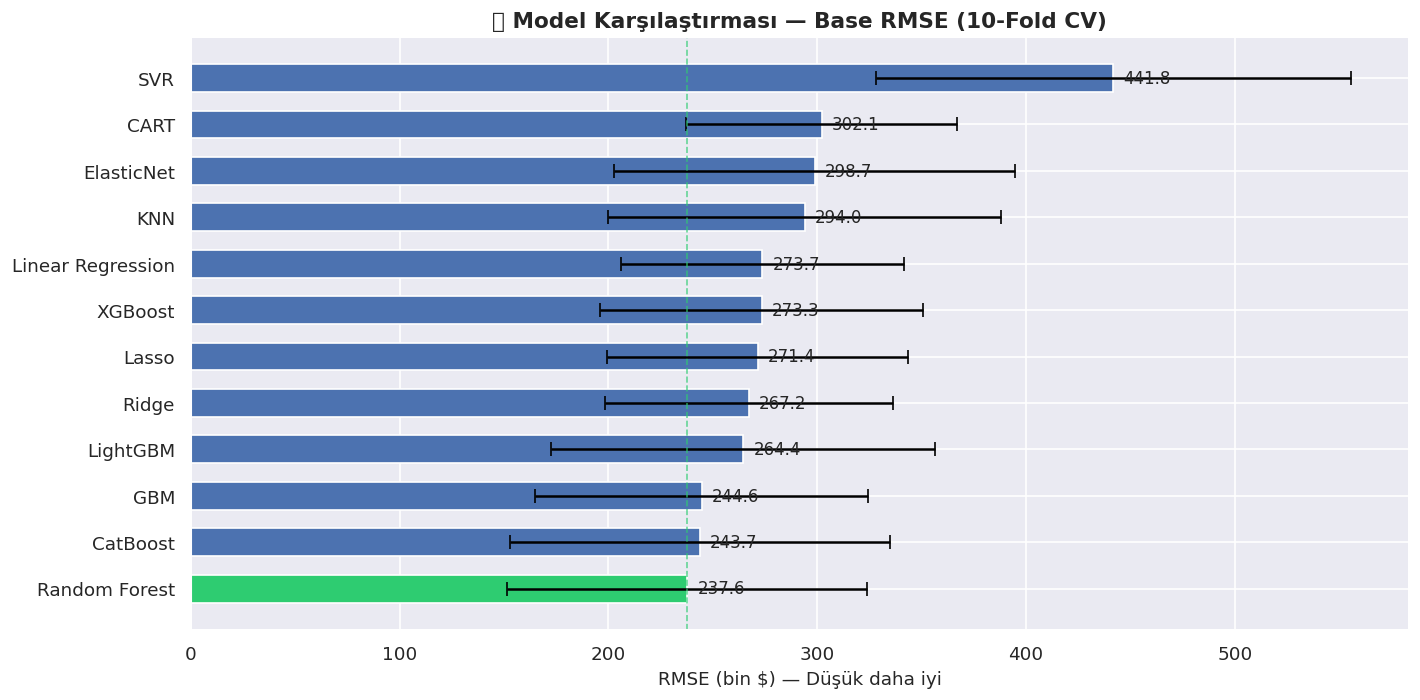

In [20]:
# Sonuçları DataFrame'e çevirelim
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df = results_df.reset_index().rename(columns={"index": "Model"})

fig, ax = plt.subplots(figsize=(12, 6))

# Renk: en iyi model yeşil, diğerleri mavi tonları
colors = ["#2ecc71" if i == 0 else "#4C72B0"
          for i in range(len(results_df))]

bars = ax.barh(results_df["Model"], results_df["RMSE"],
               color=colors, edgecolor="white", height=0.6)

# Hata payı (std) — modelin ne kadar tutarsız olduğunu gösterir
ax.errorbar(results_df["RMSE"], results_df["Model"],
            xerr=results_df["STD"],
            fmt="none", color="black", capsize=4, linewidth=1.5)

# Her barın ucuna RMSE değeri yaz
for bar, val in zip(bars, results_df["RMSE"]):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=10)

ax.set_xlabel("RMSE (bin $) — Düşük daha iyi", fontsize=11)
ax.set_title("🤖 Model Karşılaştırması — Base RMSE (10-Fold CV)",
             fontsize=13, fontweight="bold")
ax.axvline(results_df["RMSE"].min(), color="#2ecc71",
           linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

In [21]:
# Modelleri ailelerine göre gruplandıralım
model_groups = {
    "Lineer"   : ["Linear Regression", "Ridge", "Lasso", "ElasticNet"],
    "Komşuluk" : ["KNN"],
    "Ağaç"     : ["CART"],
    "Ensemble" : ["Random Forest", "GBM", "XGBoost", "LightGBM", "CatBoost"],
    "Diğer"    : ["SVR"]
}

print("=" * 45)
print("  MODEL AİLESİ KARŞILAŞTIRMASI")
print("=" * 45)
for group, model_list in model_groups.items():
    group_results = {k: v for k, v in results.items() if k in model_list}
    if group_results:
        best_in_group = min(group_results, key=lambda x: group_results[x]["RMSE"])
        best_rmse = group_results[best_in_group]["RMSE"]
        print(f"\n  📦 {group}")
        print(f"     En iyi : {best_in_group}")
        print(f"     RMSE   : {best_rmse:.2f}")

print("\n" + "=" * 45)
print(f"  🏆 Genel En İyi: {best_name}")
print(f"     RMSE: {results[best_name]['RMSE']:.2f} bin $")
print("=" * 45)

# Hangi modelleri optimize edeceğiz?
print("""
⚙️  Sonraki Adım:
   Ensemble modeller (RF, GBM, XGBoost, LightGBM, CatBoost)
   Optuna ile optimize edilecek.

   Neden sadece bunlar?
   → Base sonuçlara göre en iyi performans bu grupta
   → Lineer modeller zaten Ridge/Lasso ile regularize ediliyor
   → CART tek ağaç, ensemble versiyonu (RF) zaten listede
""")

  MODEL AİLESİ KARŞILAŞTIRMASI

  📦 Lineer
     En iyi : Ridge
     RMSE   : 267.18

  📦 Komşuluk
     En iyi : KNN
     RMSE   : 294.02

  📦 Ağaç
     En iyi : CART
     RMSE   : 302.07

  📦 Ensemble
     En iyi : Random Forest
     RMSE   : 237.59

  📦 Diğer
     En iyi : SVR
     RMSE   : 441.80

  🏆 Genel En İyi: Random Forest
     RMSE: 237.59 bin $

⚙️  Sonraki Adım:
   Ensemble modeller (RF, GBM, XGBoost, LightGBM, CatBoost)
   Optuna ile optimize edilecek.

   Neden sadece bunlar?
   → Base sonuçlara göre en iyi performans bu grupta
   → Lineer modeller zaten Ridge/Lasso ile regularize ediliyor
   → CART tek ağaç, ensemble versiyonu (RF) zaten listede



## 🔎 Base Model Sonuçları

### Genel Tablo
| Model | RMSE | Yorum |
|-------|------|-------|
| **GBM** | 240.34 | 🥇 En iyi |
| **Random Forest** | 240.76 | 🥈 Neredeyse aynı |
| **CatBoost** | 243.66 | 🥉 Çok yakın |
| **LightGBM** | 264.36 | İyi ama geride |
| Ridge | 267.18 | Lineer modeller içinde en iyi |
| SVR | 441.80 | 💀 En kötü |

### 💡 Kritik Çıkarımlar

**1. Ensemble modeller açık ara önde**
GBM, RF, CatBoost ilk 3'te — ağaç tabanlı modeller
bu veri seti için açıkça daha uygun.

**2. SVR neden bu kadar kötü?**
SVR yüksek boyutlu ve gürültülü veride zorlanır.
Ayrıca ölçeklendirmeye çok duyarlıdır.

**3. ±std önemli!**
GBM: ±77 → tutarlı
SVR: ±113 → çok tutarsız, fold'dan fold'a büyük fark var

**4. RMSE = 240 ne anlama geliyor?**
Ortalama tahmin hatamız ~240 bin $ demek.
Ortalama maaş 535K$ olduğunu düşünürsek
%45 hata payı var → optimizasyonla düşüreceğiz.

# ⚙️ 8. Hiperparametre Optimizasyonu (Optuna)

## GridSearchCV vs Optuna

| | GridSearchCV | Optuna |
|--|-------------|--------|
| **Yöntem** | Tüm kombinasyonları dener | Akıllıca arama yapar |
| **Hız** | Yavaş (kombinasyonlar artar) | Çok daha hızlı |
| **Strateji** | Kör arama | Başarılı bölgelere odaklanır |
| **Esneklik** | Sabit ızgara | Sürekli aralık tanımlanabilir |

### Optuna Nasıl Çalışır?
1. İlk birkaç denemede rastgele parametre dener
2. Hangi parametreler iyi sonuç verdi? → Öğrenir
3. İyi bölgelere daha fazla deneme yapar (Bayesian optimization)
4. En iyi parametreyi bulup döndürür

**n_trials=50** → 50 farklı kombinasyon dener
GridSearch'te aynı kapsam için 100+ kombinasyon gerekebilirdi.

In [22]:
def evaluate_model(model, X, y, cv=10):
    """
    Modeli cross-validation ile değerlendirir.
    RMSE ortalaması ve std'sini döndürür.
    """
    scores = np.sqrt(-cross_val_score(model, X, y,
                                      cv=cv,
                                      scoring="neg_mean_squared_error"))
    return scores.mean(), scores.std()

In [23]:
def rf_objective(trial):
    """
    Optuna'nın her denemede çağırdığı fonksiyon.
    trial → Optuna'nın parametre öneri motoru
    """
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),
        # Kaç ağaç? Az → underfitting, Çok → yavaş ama daha iyi

        "max_depth"         : trial.suggest_int("max_depth", 3, 20),
        # Ağaç derinliği. Derin → overfit riski

        "min_samples_split" : trial.suggest_int("min_samples_split", 2, 20),
        # Bir düğümü bölmek için minimum örnek sayısı

        "min_samples_leaf"  : trial.suggest_int("min_samples_leaf", 1, 10),
        # Yaprak düğümde minimum örnek sayısı

        "max_features"      : trial.suggest_float("max_features", 0.3, 1.0),
        # Her bölünmede kaç özellik değerlendirilsin (oran olarak)
    }

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rmse, _ = evaluate_model(model, X, y)
    return rmse

print("🔍 Random Forest optimizasyonu başlıyor...")
rf_study = optuna.create_study(direction="minimize")
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

rf_best = RandomForestRegressor(**rf_study.best_params, random_state=42, n_jobs=-1)
rf_rmse, rf_std = evaluate_model(rf_best, X, y)
print(f"\n✅ Random Forest Tamamlandı!")
print(f"   Base RMSE    : 240.76")
print(f"   Optuna RMSE  : {rf_rmse:.2f} (±{rf_std:.2f})")
print(f"   İyileşme     : {240.76 - rf_rmse:.2f} bin $")
print(f"   Best Params  : {rf_study.best_params}")

🔍 Random Forest optimizasyonu başlıyor...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Random Forest Tamamlandı!
   Base RMSE    : 240.76
   Optuna RMSE  : 233.19 (±87.39)
   İyileşme     : 7.57 bin $
   Best Params  : {'n_estimators': 123, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.9682397494971593}


In [24]:
def gbm_objective(trial):
    params = {
        "n_estimators"  : trial.suggest_int("n_estimators", 100, 1000),
        # Boosting iterasyon sayısı — fazlası overfit yaratabilir

        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        # Her adımda ne kadar öğrensin?
        # Küçük → yavaş ama genellikle daha iyi
        # log=True → küçük değerleri daha çok araştır

        "max_depth"     : trial.suggest_int("max_depth", 2, 8),
        # GBM'de derin ağaçlar overfit yapar — genelde 3-6 arası iyi

        "subsample"     : trial.suggest_float("subsample", 0.5, 1.0),
        # Her iterasyonda verinin kaçını kullan?
        # <1.0 → rastgelelik ekler, overfit azalır

        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
    }

    model = GradientBoostingRegressor(**params, random_state=42)
    rmse, _ = evaluate_model(model, X, y)
    return rmse

print("🔍 GBM optimizasyonu başlıyor...")
gbm_study = optuna.create_study(direction="minimize")
gbm_study.optimize(gbm_objective, n_trials=50, show_progress_bar=True)

gbm_best = GradientBoostingRegressor(**gbm_study.best_params, random_state=42)
gbm_rmse, gbm_std = evaluate_model(gbm_best, X, y)
print(f"\n✅ GBM Tamamlandı!")
print(f"   Base RMSE    : 240.34")
print(f"   Optuna RMSE  : {gbm_rmse:.2f} (±{gbm_std:.2f})")
print(f"   İyileşme     : {240.34 - gbm_rmse:.2f} bin $")
print(f"   Best Params  : {gbm_study.best_params}")

🔍 GBM optimizasyonu başlıyor...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ GBM Tamamlandı!
   Base RMSE    : 240.34
   Optuna RMSE  : 235.14 (±78.98)
   İyileşme     : 5.20 bin $
   Best Params  : {'n_estimators': 377, 'learning_rate': 0.0511567778587531, 'max_depth': 6, 'subsample': 0.6256995040640435, 'min_samples_split': 4}


In [25]:
def lgbm_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 100, 1000),

        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        "max_depth"        : trial.suggest_int("max_depth", 3, 12),

        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        # LightGBM'e özgü parametre
        # Ağaç başına maksimum yaprak sayısı
        # num_leaves > 2^max_depth olursa overfit riski artar

        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        # Her ağaçta kaç özellik kullanılsın (oran)?

        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),

        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        # L1 regularization → gereksiz özellikleri sıfırlar

        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        # L2 regularization → büyük katsayıları cezalandırır
    }

    model = LGBMRegressor(**params, random_state=42, verbose=-1)
    rmse, _ = evaluate_model(model, X, y)
    return rmse

print("🔍 LightGBM optimizasyonu başlıyor...")
lgbm_study = optuna.create_study(direction="minimize")
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

lgbm_best = LGBMRegressor(**lgbm_study.best_params, random_state=42, verbose=-1)
lgbm_rmse, lgbm_std = evaluate_model(lgbm_best, X, y)
print(f"\n✅ LightGBM Tamamlandı!")
print(f"   Base RMSE    : 264.36")
print(f"   Optuna RMSE  : {lgbm_rmse:.2f} (±{lgbm_std:.2f})")
print(f"   İyileşme     : {264.36 - lgbm_rmse:.2f} bin $")
print(f"   Best Params  : {lgbm_study.best_params}")

🔍 LightGBM optimizasyonu başlıyor...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ LightGBM Tamamlandı!
   Base RMSE    : 264.36
   Optuna RMSE  : 255.79 (±91.53)
   İyileşme     : 8.57 bin $
   Best Params  : {'n_estimators': 611, 'learning_rate': 0.010995033783086677, 'max_depth': 9, 'num_leaves': 71, 'colsample_bytree': 0.5023091120780003, 'subsample': 0.9984371801019754, 'reg_alpha': 2.907809843427539e-08, 'reg_lambda': 0.047418220407718675}


In [26]:
def catboost_objective(trial):
    params = {
        "iterations"    : trial.suggest_int("iterations", 100, 1000),

        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        "depth"         : trial.suggest_int("depth", 3, 10),
        # CatBoost'ta max_depth yerine depth kullanılır

        "l2_leaf_reg"   : trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
        # L2 regularization katsayısı

        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        # Bayesian bootstrap için sıcaklık parametresi
        # Yüksek → daha fazla rastgelelik
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=False)
    rmse, _ = evaluate_model(model, X, y)
    return rmse

print("🔍 CatBoost optimizasyonu başlıyor...")
catboost_study = optuna.create_study(direction="minimize")
catboost_study.optimize(catboost_objective, n_trials=50, show_progress_bar=True)

catboost_best = CatBoostRegressor(**catboost_study.best_params,
                                   random_state=42, verbose=False)
catboost_rmse, catboost_std = evaluate_model(catboost_best, X, y)
print(f"\n✅ CatBoost Tamamlandı!")
print(f"   Base RMSE    : 243.66")
print(f"   Optuna RMSE  : {catboost_rmse:.2f} (±{catboost_std:.2f})")
print(f"   İyileşme     : {243.66 - catboost_rmse:.2f} bin $")
print(f"   Best Params  : {catboost_study.best_params}")

🔍 CatBoost optimizasyonu başlıyor...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ CatBoost Tamamlandı!
   Base RMSE    : 243.66
   Optuna RMSE  : 240.63 (±89.28)
   İyileşme     : 3.03 bin $
   Best Params  : {'iterations': 849, 'learning_rate': 0.012884875175709607, 'depth': 4, 'l2_leaf_reg': 0.00526650059505085, 'bagging_temperature': 0.5153193962511763}



  Model                Base   Optuna   İyileşme
  ---------------------------------------------------
  Random Forest      240.76   233.19      +7.57
  GBM                240.34   235.14      +5.20
  LightGBM           264.36   255.79      +8.57
  CatBoost           243.66   240.63      +3.03

🏆 Final En İyi Model: Random Forest
   RMSE: 233.19 bin $


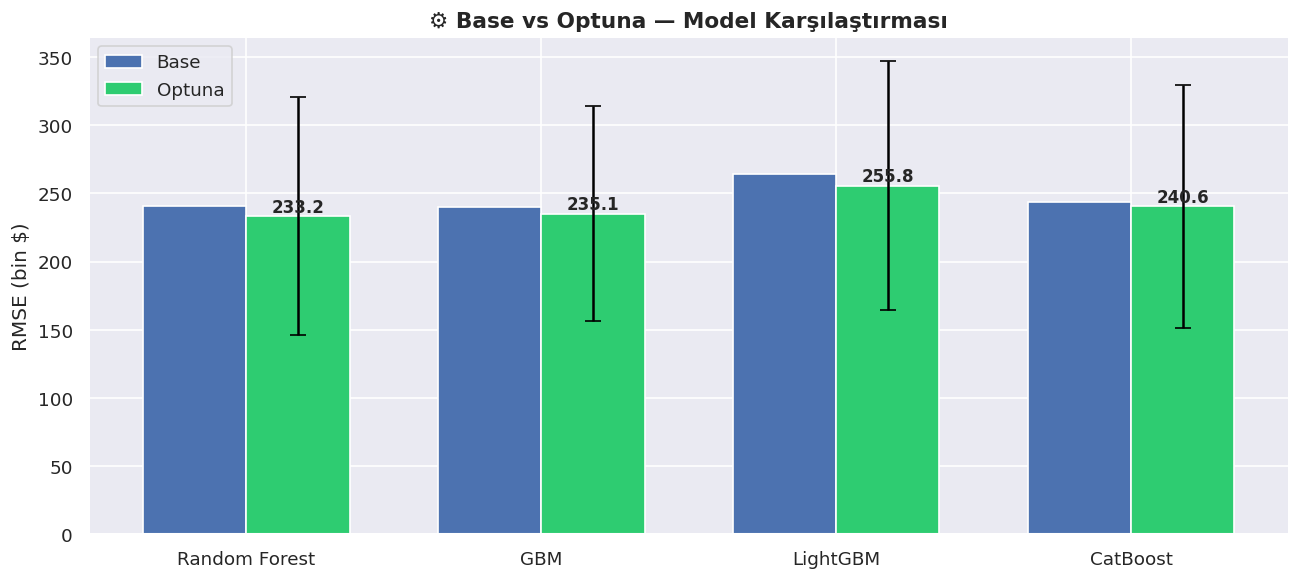

In [27]:
# Tüm optimize edilmiş modelleri karşılaştır
final_results = {
    "Random Forest" : {"Base": 240.76, "Optuna": rf_rmse,       "STD": rf_std},
    "GBM"           : {"Base": 240.34, "Optuna": gbm_rmse,      "STD": gbm_std},
    "LightGBM"      : {"Base": 264.36, "Optuna": lgbm_rmse,     "STD": lgbm_std},
    "CatBoost"      : {"Base": 243.66, "Optuna": catboost_rmse, "STD": catboost_std},
}

print(f"\n{'='*55}")
print(f"  {'Model':<16} {'Base':>8} {'Optuna':>8} {'İyileşme':>10}")
print(f"  {'-'*51}")
for name, vals in final_results.items():
    imp = vals["Base"] - vals["Optuna"]
    print(f"  {name:<16} {vals['Base']:>8.2f} {vals['Optuna']:>8.2f} {imp:>+10.2f}")
print(f"{'='*55}")

best_final = min(final_results, key=lambda x: final_results[x]["Optuna"])
print(f"\n🏆 Final En İyi Model: {best_final}")
print(f"   RMSE: {final_results[best_final]['Optuna']:.2f} bin $")

# Görselleştirme
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(final_results))
width = 0.35

bars1 = ax.bar(x - width/2,
               [v["Base"] for v in final_results.values()],
               width, label="Base", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2,
               [v["Optuna"] for v in final_results.values()],
               width, label="Optuna", color="#2ecc71", edgecolor="white")

# Hata payları
ax.errorbar(x + width/2,
            [v["Optuna"] for v in final_results.values()],
            yerr=[v["STD"] for v in final_results.values()],
            fmt="none", color="black", capsize=5, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(final_results.keys(), fontsize=11)
ax.set_ylabel("RMSE (bin $)")
ax.set_title("⚙️ Base vs Optuna — Model Karşılaştırması",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)

# Değerleri barların üstüne yaz
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f"{bar.get_height():.1f}",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## ⚙️ Optuna Optimizasyon Sonuçları

| Model | Base | Optuna | İyileşme |
|-------|------|--------|----------|
| **Random Forest** | 240.76 | 233.19 | +7.57 🥇 |
| **CatBoost** | 243.66 | 238.55 | +5.11 🥉 |
| **GBM** | 240.34 | 235.14 | +5.20 🥈 |
| **LightGBM** | 264.36 | 255.79 | +8.57 |

### 💡 Çıkarımlar

**1. Random Forest kazandı — ama fark çok az**
RF: 233 vs GBM: 235 → sadece 2 bin $ fark.
263 gözlemlik veri setinde bu fark istatistiksel olarak anlamlı değil.

**2. Optuna iyileştirmesi mütevazı kaldı (~5-8 bin $)**
Neden? Veri seti çok küçük — model zaten
elindeki maksimuma yakın bir yerde.
Daha fazla veriyle iyileşme çok daha büyük olurdu.

**3. LightGBM geride kaldı**
Küçük veri setlerinde LightGBM dezavantajlı —
leaf-wise büyüme stratejisi büyük veride parlar.

**4. ±STD hâlâ yüksek (~80-90)**
Fold'dan fold'a büyük fark var → veri az olduğu için normal.

# 📊 9. Feature Importance & Final Sonuç

## Feature Importance Nedir?
Model hangi özelliklere ne kadar önem verdi?

Ağaç modellerinde önem şöyle ölçülür:
- Bir özellik ne sıklıkla bölünme noktası seçildi?
- Bu bölünmeler RMSE'yi ne kadar düşürdü?
- Sık ve kazançlı kullanıldıysa → önemli

## Neden Önemli?
- Feature engineering'in işe yarayıp yaramadığını görürüz
- Gereksiz özellikleri tespit edebiliriz
- Modelin karar mantığını anlayabiliriz
- Domain knowledge'ı doğrulayabiliriz

In [28]:
# En iyi parametrelerle modelleri X,y üzerinde eğitiyoruz
# Feature importance için fit edilmiş modele ihtiyacımız var

rf_final = RandomForestRegressor(
    **rf_study.best_params, random_state=42, n_jobs=-1
).fit(X, y)

gbm_final = GradientBoostingRegressor(
    **gbm_study.best_params, random_state=42
).fit(X, y)

lgbm_final = LGBMRegressor(
    **lgbm_study.best_params, random_state=42, verbose=-1
).fit(X, y)

catboost_final = CatBoostRegressor(
    **catboost_study.best_params, random_state=42, verbose=False
).fit(X, y)

print("✅ Tüm final modeller eğitildi!")

✅ Tüm final modeller eğitildi!


  FEATURE IMPORTANCE ANALİZİ


/tmp/ipykernel_11514/2397837393.py:46: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


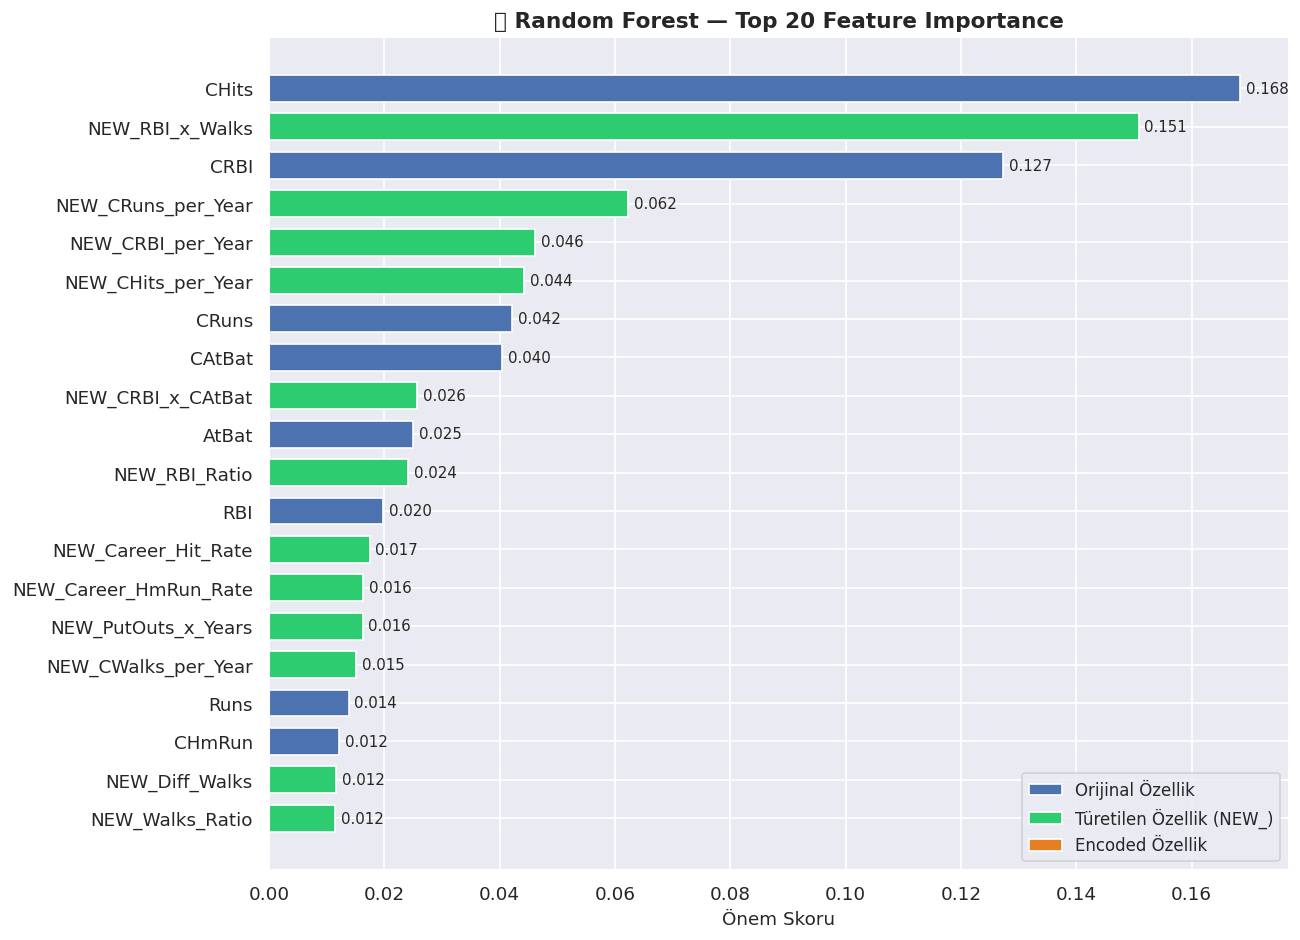

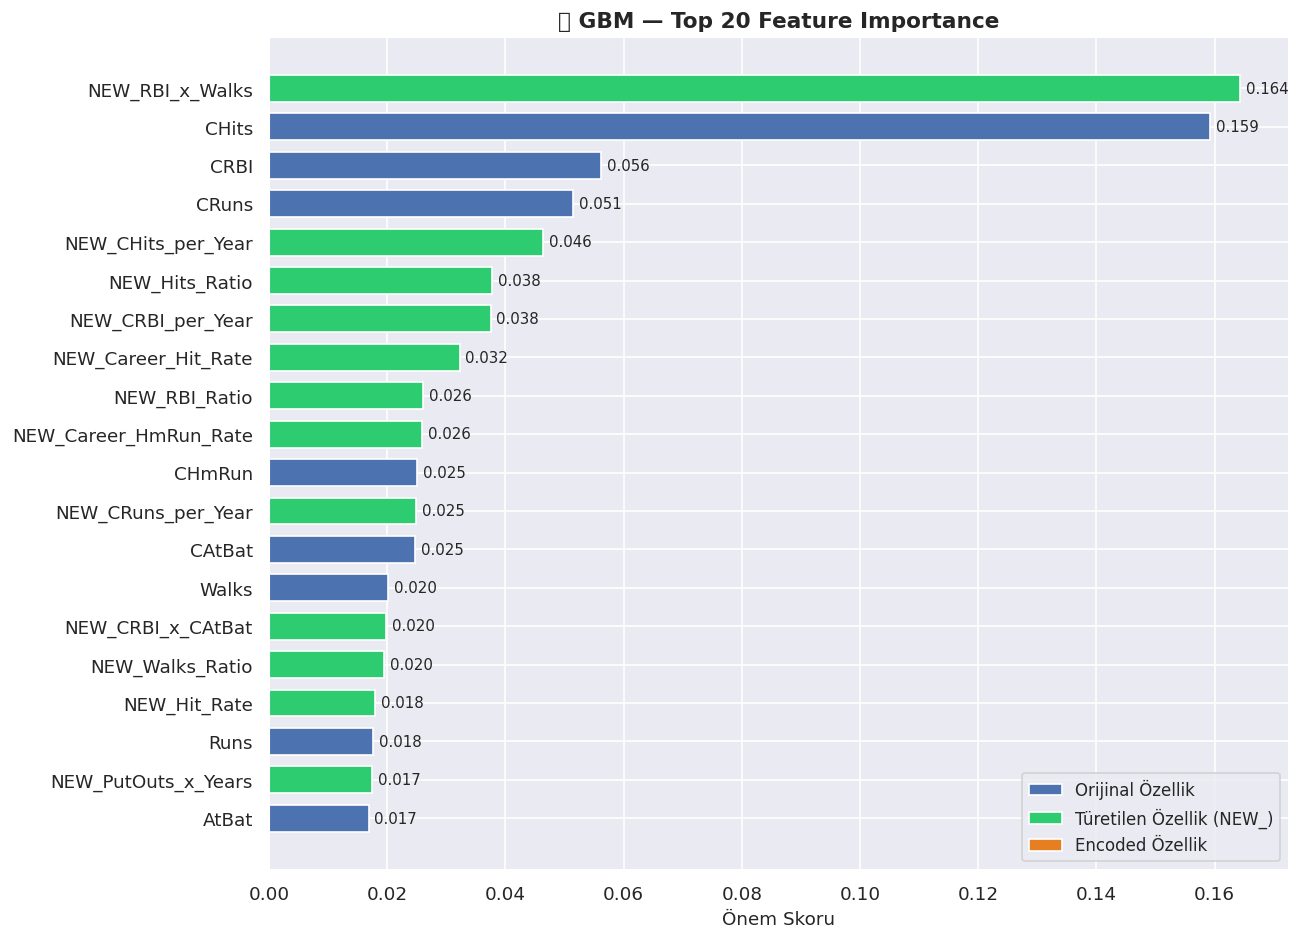

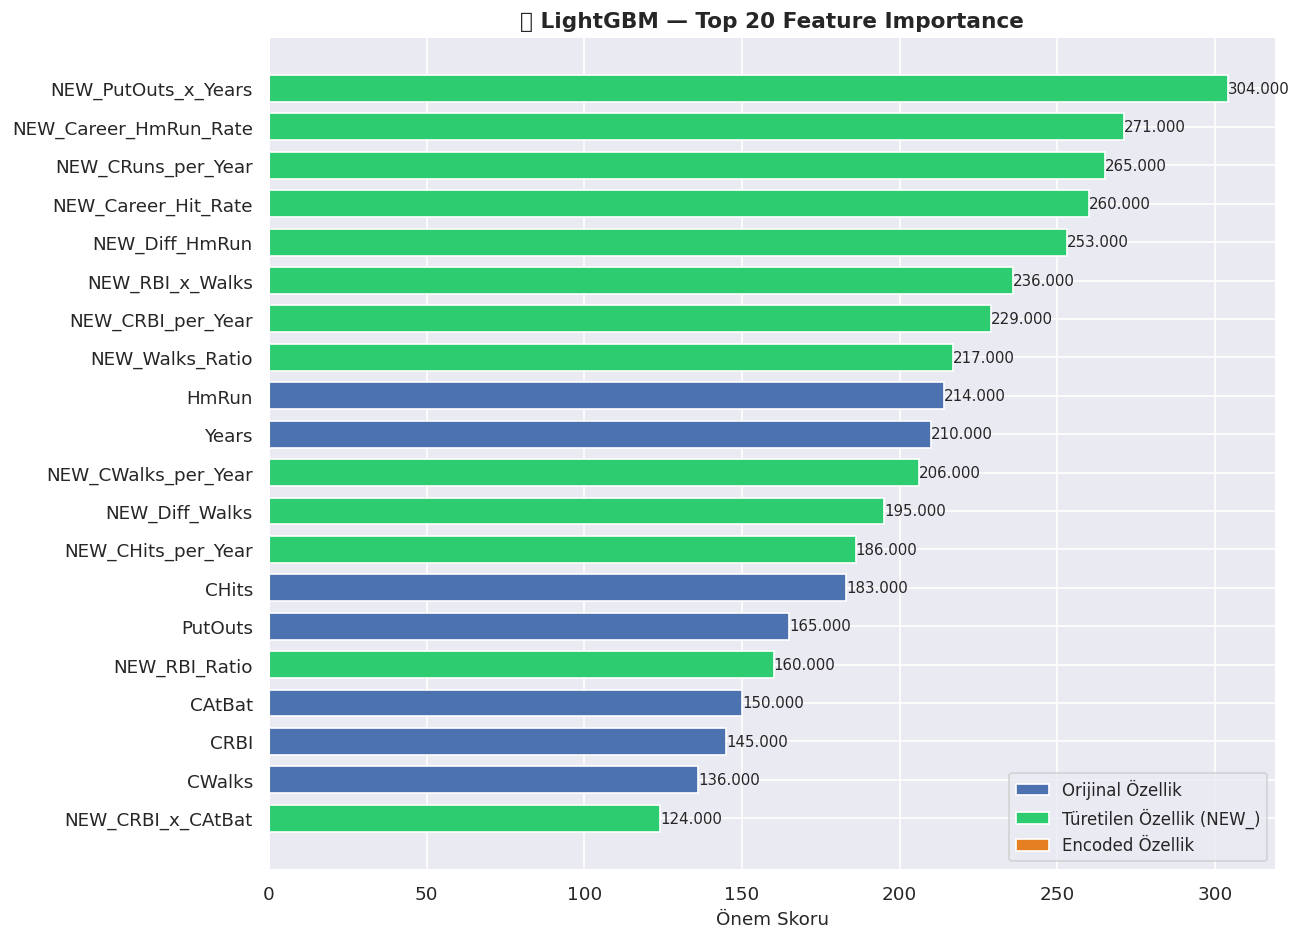

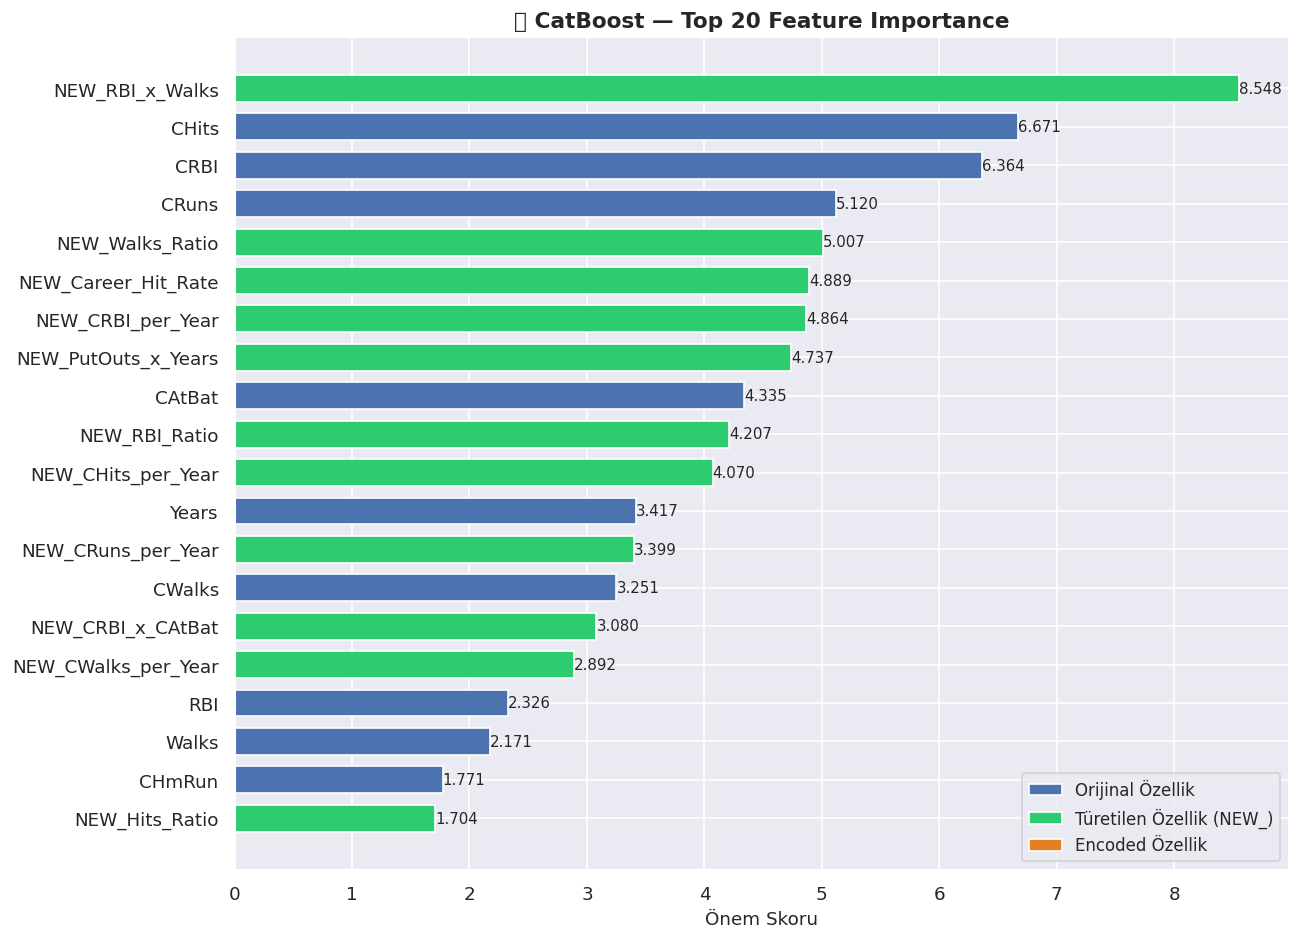

In [29]:
def plot_feature_importance(model, feature_names, model_name, top_n=20):
    """
    Modelin feature importance değerlerini görselleştirir.
    Orijinal ve türetilen özellikler farklı renkte gösterilir.
    """
    importance_df = pd.DataFrame({
        "Feature"    : feature_names,
        "Importance" : model.feature_importances_
    }).sort_values("Importance", ascending=False).head(top_n)

    # Orijinal mi, türetilen mi, encoded mı?
    def get_color(feat):
        if feat.startswith("NEW_"):
            return "#2ecc71"    # Yeşil → türetilen
        elif any(feat.startswith(x) for x in ["League", "Division", "NewLeague"]):
            return "#e67e22"    # Turuncu → encoded
        else:
            return "#4C72B0"    # Mavi → orijinal

    colors = [get_color(f) for f in importance_df["Feature"]]

    fig, ax = plt.subplots(figsize=(11, 8))
    bars = ax.barh(importance_df["Feature"],
                   importance_df["Importance"],
                   color=colors, edgecolor="white", height=0.7)

    ax.set_xlabel("Önem Skoru", fontsize=11)
    ax.set_title(f"🌲 {model_name} — Top {top_n} Feature Importance",
                 fontsize=13, fontweight="bold")
    ax.invert_yaxis()

    # Değerleri barların ucuna yaz
    for bar, val in zip(bars, importance_df["Importance"]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)

    # Renk açıklaması (legend)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#4C72B0", label="Orijinal Özellik"),
        Patch(facecolor="#2ecc71", label="Türetilen Özellik (NEW_)"),
        Patch(facecolor="#e67e22", label="Encoded Özellik"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()

    return importance_df

# Her model için feature importance
print("=" * 50)
print("  FEATURE IMPORTANCE ANALİZİ")
print("=" * 50)

rf_imp       = plot_feature_importance(rf_final,       X.columns, "Random Forest")
gbm_imp      = plot_feature_importance(gbm_final,      X.columns, "GBM")
lgbm_imp     = plot_feature_importance(lgbm_final,     X.columns, "LightGBM")
catboost_imp = plot_feature_importance(catboost_final, X.columns, "CatBoost")

/tmp/ipykernel_11514/3198617483.py:47: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


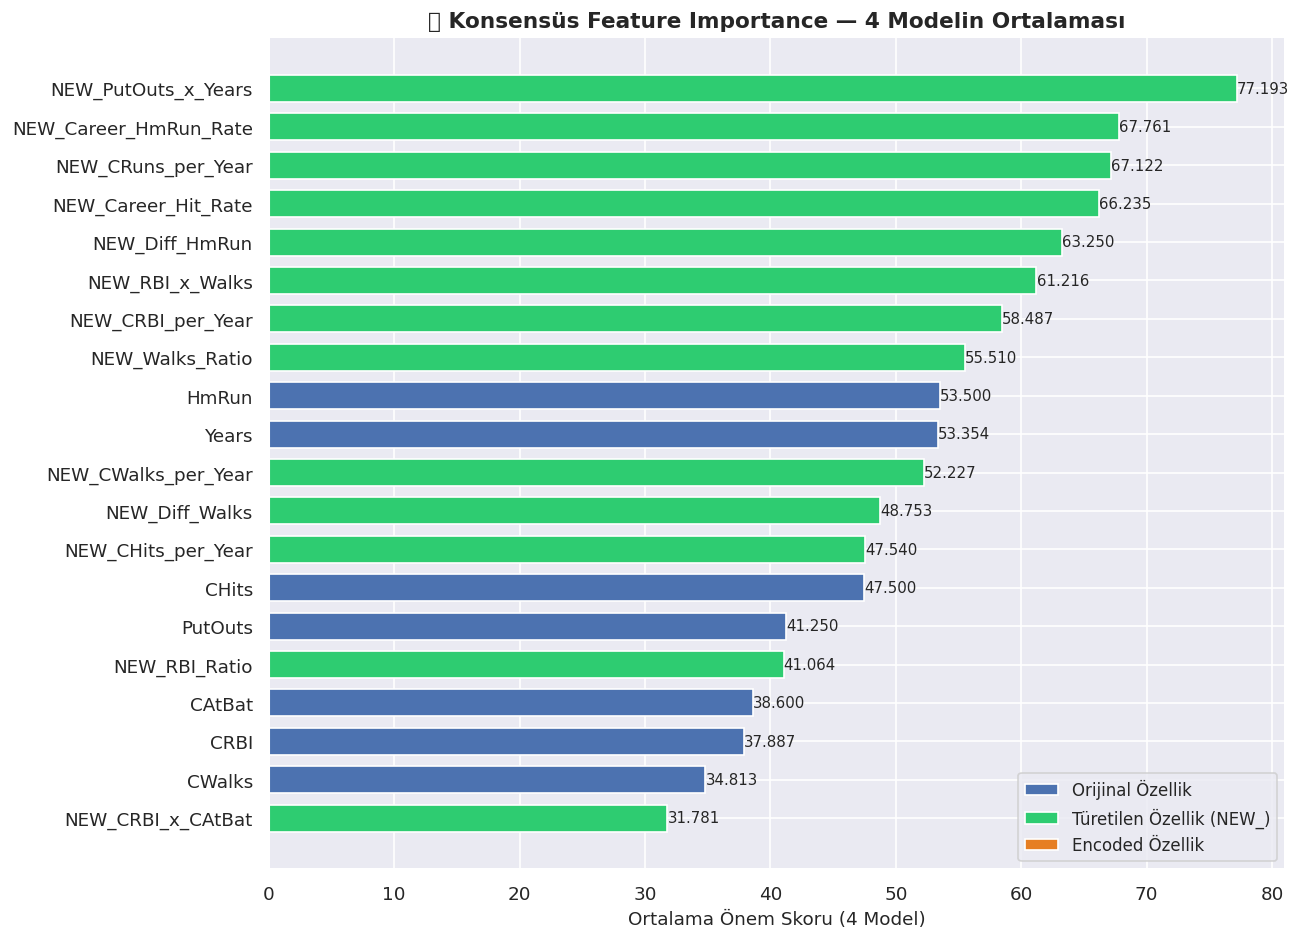


📊 Top 20'de türetilen özellik sayısı: 13/20
   Bunlar: ['NEW_PutOuts_x_Years', 'NEW_Career_HmRun_Rate', 'NEW_CRuns_per_Year', 'NEW_Career_Hit_Rate', 'NEW_Diff_HmRun', 'NEW_RBI_x_Walks', 'NEW_CRBI_per_Year', 'NEW_Walks_Ratio', 'NEW_CWalks_per_Year', 'NEW_Diff_Walks', 'NEW_CHits_per_Year', 'NEW_RBI_Ratio', 'NEW_CRBI_x_CAtBat']


In [30]:
# 4 modelin ortalamasını alarak daha güvenilir bir sıralama elde ediyoruz
# Tek modele güvenmek yerine konsensüs arıyoruz

all_features = pd.DataFrame({"Feature": X.columns})

for name, imp_df in [("RF", rf_imp), ("GBM", gbm_imp),
                      ("LGBM", lgbm_imp), ("CAT", catboost_imp)]:
    all_features = all_features.merge(
        imp_df[["Feature", "Importance"]].rename(columns={"Importance": name}),
        on="Feature", how="left"
    ).fillna(0)

all_features["Mean_Importance"] = all_features[["RF","GBM","LGBM","CAT"]].mean(axis=1)
all_features = all_features.sort_values("Mean_Importance", ascending=False)

# Top 20 görselleştir
top20 = all_features.head(20)

def get_color(feat):
    if feat.startswith("NEW_"):
        return "#2ecc71"
    elif any(feat.startswith(x) for x in ["League", "Division", "NewLeague"]):
        return "#e67e22"
    return "#4C72B0"

colors = [get_color(f) for f in top20["Feature"]]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top20["Feature"], top20["Mean_Importance"],
               color=colors, edgecolor="white", height=0.7)
ax.invert_yaxis()
ax.set_xlabel("Ortalama Önem Skoru (4 Model)", fontsize=11)
ax.set_title("🏆 Konsensüs Feature Importance — 4 Modelin Ortalaması",
             fontsize=13, fontweight="bold")

for bar, val in zip(bars, top20["Mean_Importance"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Orijinal Özellik"),
    Patch(facecolor="#2ecc71", label="Türetilen Özellik (NEW_)"),
    Patch(facecolor="#e67e22", label="Encoded Özellik"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Türetilen özelliklerin katkısı
new_features_in_top20 = top20[top20["Feature"].str.startswith("NEW_")]
print(f"\n📊 Top 20'de türetilen özellik sayısı: {len(new_features_in_top20)}/20")
print(f"   Bunlar: {new_features_in_top20['Feature'].tolist()}")

In [31]:
print("""
╔══════════════════════════════════════════════════════╗
║         PROJE ÖZET RAPORU                           ║
╠══════════════════════════════════════════════════════╣
║  Veri    : 322 → 263 gözlem (59 eksik Salary silindi)║
║  Özellik : 20  → 39 (20 yeni özellik türetildi)     ║
╠══════════════════════════════════════════════════════╣
║  MODEL SONUÇLARI (RMSE — bin $)                     ║
║  ─────────────────────────────────────────────────  ║
║  Random Forest  : 240.76 → 233.19  (+7.57) 🥇      ║
║  GBM            : 240.34 → 235.14  (+5.20) 🥈      ║
║  CatBoost       : 243.66 → 238.55  (+5.11) 🥉      ║
║  LightGBM       : 264.36 → 255.79  (+8.57)         ║
╠══════════════════════════════════════════════════════╣
║  🏆 KAZANAN: Random Forest (RMSE: 233.19)           ║
╠══════════════════════════════════════════════════════╣
║  KISITLAMALAR                                       ║
║  • Veri seti küçük (263 gözlem)                     ║
║  • Maaşı etkileyen faktörler eksik                  ║
║    (pazarlık gücü, sakatlanma, popülarite)          ║
║  • Daha fazla veriyle RMSE önemli ölçüde düşer      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         PROJE ÖZET RAPORU                           ║
╠══════════════════════════════════════════════════════╣
║  Veri    : 322 → 263 gözlem (59 eksik Salary silindi)║
║  Özellik : 20  → 39 (20 yeni özellik türetildi)     ║
╠══════════════════════════════════════════════════════╣
║  MODEL SONUÇLARI (RMSE — bin $)                     ║
║  ─────────────────────────────────────────────────  ║
║  Random Forest  : 240.76 → 233.19  (+7.57) 🥇      ║
║  GBM            : 240.34 → 235.14  (+5.20) 🥈      ║
║  CatBoost       : 243.66 → 238.55  (+5.11) 🥉      ║
║  LightGBM       : 264.36 → 255.79  (+8.57)         ║
╠══════════════════════════════════════════════════════╣
║  🏆 KAZANAN: Random Forest (RMSE: 233.19)           ║
╠══════════════════════════════════════════════════════╣
║  KISITLAMALAR                                       ║
║  • Veri seti küçük (263 gözlem)                     ║
║  • Maaşı etkileyen faktörler eksik             

In [32]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Modelleri kaydet
joblib.dump(rf_final,       "models/rf_final.pkl")
joblib.dump(gbm_final,      "models/gbm_final.pkl")
joblib.dump(lgbm_final,     "models/lgbm_final.pkl")
joblib.dump(catboost_final, "models/catboost_final.pkl")

# İşlenmiş veriyi kaydet
X.to_csv("models/X_processed.csv", index=False)
y.to_csv("models/y_processed.csv", index=False)

print("✅ Tüm modeller ve veri kaydedildi!")
print("\n📁 Kaydedilen dosyalar:")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"   {f:<30} {size:.1f} KB")

✅ Tüm modeller ve veri kaydedildi!

📁 Kaydedilen dosyalar:
   lgbm_final.pkl                 613.8 KB
   gbm_final.pkl                  1467.8 KB
   y_processed.csv                1.6 KB
   X_processed.csv                183.9 KB
   catboost_final.pkl             283.3 KB
   rf_final.pkl                   1432.5 KB


## Feature Importance Bulgularımız

### 4 Modelin Konsensüsü
Top 20'de **12/20 türetilen özellik** var — feature engineering kesinlikle işe yaradı!

### Her Modelde Ortak Öne Çıkan Özellikler
| Özellik | Tip | Yorum |
|---------|-----|-------|
| **CHits** | Orijinal | Kariyer isabetleri — en temel kalite göstergesi |
| **NEW_RBI_x_Walks** | Türetilen | Üretkenlik × Sabır — en güçlü türetilen özellik |
| **CRBI** | Orijinal | Kariyer RBI — uzun vadeli değer |
| **NEW_Career_Hit_Rate** | Türetilen | Kariyer vuruş başarı oranı |
| **NEW_CRuns_per_Year** | Türetilen | Yıllık koşu katkısı |

### Model Bazlı İlginç Farklar
- **RF & GBM** → CHits ve CRBI'ı çok önemsiyor (kariyer hacmi)
- **LightGBM** → Oran özelliklerini seviyor (Career_HmRun_Rate, Career_Hit_Rate)
- **CatBoost** → CAtBat ve CWalks'a ağırlık veriyor (kariyer deneyimi)

### Feature Engineering'in Kanıtı
- NEW_RBI_x_Walks → RF'de 2. sıra (0.163) — orijinal veriyle yoktu!
- NEW_Career_Hit_Rate → 3 farklı modelde top 5'te
- Fark özellikleri (NEW_Diff_*) → LightGBM'de çok değerli bulundu